Analysis of 2D noise properties. If you already have generated the noise*nc file you can use the more simple notebook: noise_analysis_2D_only_20km_L2_med_from_segments.ipynb

The present notebook generates the noise*nc  file from various data sources (spectra of SSH and model output)

In [1]:
# Extend the analysis of Zhang & Callies to 2D spectra
# see : https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2025JC022879
# first tests use the track most used in their paper: 

import netCDF4 as nc
import glob
import xarray as xr
import xrft
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd

from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.special import gamma, kv
from numpy.linalg import inv
import mpmath as mp
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import math
from math import sin, cos, sqrt, atan2, radians

from matplotlib import pyplot as plt, animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import swot_analysis as swot
import scipy.signal as signal
from scipy.signal import detrend

import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.io as sio
from scipy.stats import chi2
import scipy.stats as stats
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys as sys
import glob
import os

sys.path.append('../src/')
import swot_swell_utils as swell
from pathlib import Path
from paths import *


from  lib_filters_obp import *
from  spectral_analysis_functions import *
import matplotlib.colors as mcolors
import cmocean
import cmocean.cm as cmo

from ipywidgets import interact, IntSlider, FloatRangeSlider,  FloatSlider, ToggleButtons
from ipywidgets import interactive_output, GridBox, Layout
from IPython.display import display
from ipywidgets import VBox

#import h5py


In [2]:
pth_WW3_trck='/media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/';runtag='GLOBIG';prefix='SWOTIG_WW3-GLOB-30M';nIG=19

specres="SR3"
nfy=21;nfx=20
yCTind=10;xCTind=14;yATind=13;xATind=10

#specres="SR4"
#nfy=42;nfx=40
#yCTind=10;xCTind=28;yATind=27;xATind=20

#specres="SR5"
#nfy=84;nfx=80
#yCTind=41;xCTind=56;yATind=54;xATind=40


specfolder="L2_D_WindWave_"+specres

pass_number = 28
lat_min = -56.5
lat_max = -53.5
min_cycle = 474
max_cycle = 578
ana_tag='L2_D_"+specres+"_calval_pass28';mss_tag='pass28_55S'
annotation_points = [(17,3,'E'),(123,3,'C'),(183,7,'A'),(171,6,'F'),(110,6,'D'),(183,1,'B')]

#pass_number = 82
#min_cycle = 3
#max_cycle = 42
#lat_min = 35
#lat_max = 48
#"ana_tag="L2_D_"+specres+"_pass82";mss_tag='pass82_45N'
#annotation_points = []

pass_number = 3
min_cycle = 474
max_cycle = 578
lat_min = 40.4 #-56.5
lat_max = 42.8 #-53.5
ana_tag='L2_D_'+specres+'_calval_pass03';mss_tag='pass_calval_03_42N'
annotation_points = [(73,2,'M'),(91,2,'N'),(104,2,'O')]


#specfolder="L2_D_WindWave_res3u"
#pass_number = 24
#min_cycle = 1
#max_cycle = 48
#lat_min = 42 #-56.5
#lat_max = 49 #-53.5
#ana_tag='L2_D_'+specres+'_pass24';mss_tag='pass_calval_24_45N'

#pass_number = 52
#min_cycle = 1
#max_cycle = 48
#lat_min = 42 #-56.5
#lat_max = 49 #-53.5
#ana_tag='L2_D_'+specres+'_pass52';mss_tag='pass_calval_52_45N'


model_files = sorted(wavemodel_CCI_folder.glob("CCI_WW3-GLOB-30M_202???_hs.nc"))

spass= f"{pass_number:03d}"
print(spass,'##',model_files)


path2=str(swot_WindWave_L2_D_folder)
num_cycles = max_cycle - min_cycle + 1

003 ## [PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202401_hs.nc'), Posi

In [4]:
# find the first cycle which contains the selected path
found_nothing = True
cycle = min_cycle - 1

while (found_nothing == True):
    cycle +=1
    print('test:',str(swot_Basic_L2_D_folder)+'/*/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    path = glob.glob(str(swot_Basic_L2_D_folder)+'/*/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    print('cycle:',cycle,path)
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        found_nothing = False

if (found_nothing == False):
    print(path)

test: /media/ardhuin/FabLinux/SWOT2/Basic_D/*/SWOT_L2_LR_SSH_Basic_474_003_*.nc
cycle: 474 ['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_474/SWOT_L2_LR_SSH_Basic_474_003_20230328T234416_20230329T003523_PGD0_02.nc']
['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_474/SWOT_L2_LR_SSH_Basic_474_003_20230328T234416_20230329T003523_PGD0_02.nc']


In [5]:
first_pass_data = nc.Dataset(path[0], 'r')
fp_latitude = first_pass_data['latitude']
fp_shape = np.shape(fp_latitude)
# left_edge = fp_shape[1] - 6
#we are ignoring the five outer grid points, but subtract 6 because of Python's zero indexing
lat_edge = fp_latitude[:,35]

#find min and max line indices
indx = np.nonzero((lat_edge >= lat_min) & (lat_edge <= lat_max))[0]
track_length = np.shape(indx)[0]
print(track_length)

137


In [6]:
#find cycles with given pass
cycle_list = np.empty(0)
num_useful_cycles = 0
for cycle in range(min_cycle,max_cycle+1):
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    path = glob.glob(str(swot_Basic_L2_D_folder)+'/*/'+'SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        cycle_list = np.append(cycle_list,cycle)
        num_useful_cycles += 1

print(num_useful_cycles)

100


In [10]:
lat_array = np.empty((num_useful_cycles,2,track_length,25))
lat_array[:] = np.nan
lon_array = np.empty((num_useful_cycles,2,track_length,25))
lon_array[:] = np.nan
ssha_array = np.empty((num_useful_cycles,2,track_length,25))
ssha_array[:] = np.nan
n_cross = 20     #  cross-track pixels used for 2D FFT 
uncert_array = np.empty((num_useful_cycles,2,track_length,n_cross))
uncert_array[:] = np.nan
sig0_array = np.empty((num_useful_cycles,2,track_length,25))
sig0_array[:] = np.nan
tides = np.empty((num_useful_cycles,2,track_length,25))
tides[:] = np.nan
time_array = np.empty((num_useful_cycles,2,track_length))
time_array[:] = np.nan
num_useful_strips = 0
num_bad_strips = 0

good_strips_list = np.array([[0,0]])
flag_strips_list=np.array([[0,0]])
for n,cycle in enumerate(cycle_list):
    path = glob.glob(str(swot_Basic_L2_D_folder)+'/*/SWOT_L2_LR_SSH_Basic_'+str(int(cycle)).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    data = nc.Dataset(path[0],'r')
    ssha_strip = data['ssha_karin_2'][indx,:]
    uncert= data['ssh_karin_uncert'][indx,:]
    # ssha_strip = data['ssha_karin'][indx,:]
    ssha_qual = data['ssha_karin_2_qual'][indx,:]
    xover_cor = data['height_cor_xover'][indx,:]# Additional correction provided by SWOT
    xover_cor_qual = data['height_cor_xover_qual'][indx,:]# Additional quality flag
    internal_tide_hret = data['internal_tide_hret'][indx,:] #internal tide correction I will add back  
    lat_strip = data['latitude'][indx,:]
    lon_strip = data['longitude'][indx,:]
    time_strip = data['time'][indx]
    for side in range(2):
        start_index = 5 + 34*side
        if np.ma.is_masked(ssha_strip[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        if np.ma.is_masked(xover_cor[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        flagstrip=0
        if np.any(ssha_qual[:,start_index:(start_index + 25)]) == True: 
            flagstrip=1
            flag_strips_list = np.concatenate((flag_strips_list,[[n,side]]))
        #    num_bad_strips +=1
        #    continue
        num_useful_strips +=1
        lat_array[n,side,:,:] = lat_strip[:,start_index:(start_index + 25)]
        lon_array[n,side,:,:] = lon_strip[:,start_index:(start_index + 25)]
        ssha_array[n,side,:,:] = ssha_strip[:,start_index:(start_index + 25)] + xover_cor[:,start_index:(start_index + 25)] - internal_tide_hret[:,start_index:(start_index + 25)]
        if side==1:
            start_u=3+start_index
        else:
            start_u=2+start_index
        uncert_array[n,side,:,:] = uncert[:,start_u:start_u+n_cross]
        tides[n,side,:,:] = internal_tide_hret[:,start_index:(start_index + 25)]
        time_array[n,side,:] = time_strip
        good_strips_list = np.concatenate((good_strips_list,[[n,side]]))
    data.close()
good_strips_list = np.delete(good_strips_list,0,0)
flag_strips_list = np.delete(flag_strips_list,0,0)

In [11]:
print(num_useful_strips)
print(np.shape(ssha_array))
print(np.shape(flag_strips_list),type(flag_strips_list))
#print(flag_strips_list)

190
(100, 2, 137, 25)
(39, 2) <class 'numpy.ndarray'>


In [12]:
# # time-mean and filtered time-mean of SSH (for each of the swath)
print('shape of ssha_array:',np.shape(ssha_array))
print('shape of lat_array:',np.shape(lat_array))
ssha_mean_all = np.nanmean(ssha_array,axis=0)
ssha_med_all = np.nanmedian(ssha_array,axis=0)
print('shape of ssha_mean_all array:',np.shape(ssha_mean_all))

# Get the dynamic shape from ssha_array
n_cross = 25

# Initialize output arrays with the correct shape
ssha_mean = np.full((2, track_length, n_cross), np.nan)
ssha_med = np.full((2, track_length, n_cross), np.nan)

# Loop over each side
for side in [0, 1]:
    # Get all good strips for this side
    side_mask = (good_strips_list[:, 1] == side)
    good_n_side = good_strips_list[side_mask, 0]

    # Stack all good strips for this side
    if len(good_n_side) > 0:
        ssha_side = np.stack([ssha_array[n, side, :, :] for n in good_n_side])
        ssha_mean[side, :, :] = np.nanmean(ssha_side, axis=0)
        ssha_med[side, :, :] = np.nanmedian(ssha_side, axis=0)
print('shape of ssha_mean array:',np.shape(ssha_mean))



shape of ssha_array: (100, 2, 137, 25)
shape of lat_array: (100, 2, 137, 25)
shape of ssha_mean_all array: (2, 137, 25)
shape of ssha_mean array: (2, 137, 25)


In [13]:
# 2D Gaussian filter
cutoff_m = 100e3  
delta = 2e3
# Convert cutoff to sigma in pixels (Gaussian sigma ~ cutoff / (2 * sqrt(2 * ln(2)))
sigma_m = cutoff_m / (2 * np.sqrt(2 * np.log(2)))  # FWHM to sigma
sigma_pixels = sigma_m / delta

# Apply low-pass Gaussian filter
lowpass = gaussian_filter(ssha_mean, sigma=(0, sigma_pixels, sigma_pixels))  # no smoothing in time axis
lowpassm = gaussian_filter(ssha_med, sigma=(0, sigma_pixels, sigma_pixels))  # no smoothing in time axis

# High-pass filter: original - low-pass
ssha_mean_gaussian = ssha_mean - lowpass
ssha_med_gaussian = ssha_med - lowpass

import netCDF4 as nc

# Define the output filename
output_file = mss_tag+'_mss.nc'

# Create a new NetCDF file
with nc.Dataset(output_file, 'w', format='NETCDF4') as ncfile:

    # Create dimensions
    ncfile.createDimension('side', 2)
    ncfile.createDimension('along_track', track_length)
    ncfile.createDimension('cross_track', n_cross)

    # Create variables and set attributes
    # Latitude
    lat = ncfile.createVariable('latitude', 'f4', ('side', 'along_track', 'cross_track'))
    lat.units = 'degrees_north'
    lat.long_name = 'Latitude'

    # Longitude
    lon = ncfile.createVariable('longitude', 'f4', ('side', 'along_track', 'cross_track'))
    lon.units = 'degrees_east'
    lon.long_name = 'Longitude'

    # Mean SSH
    ssha_mean_var = ncfile.createVariable('ssha_mean', 'f4', ('side', 'along_track', 'cross_track'))
    ssha_mean_var.units = 'meters'
    ssha_mean_var.long_name = 'Mean Sea Surface Height Anomaly'

    # Median SSH
    ssha_med_var = ncfile.createVariable('ssha_med', 'f4', ('side', 'along_track', 'cross_track'))
    ssha_med_var.units = 'meters'
    ssha_med_var.long_name = 'Median Sea Surface Height Anomaly'

    # Write data to variables
    lat[:, :, :] = np.nanmedian(lat_array,axis=0)
    lon[:, :, :] = np.nanmedian(lon_array,axis=0)
    ssha_mean_var[:, :, :] = ssha_mean_gaussian
    ssha_med_var[:, :, :] = ssha_med_gaussian

    # Add global attributes
    ncfile.title = 'Averaged SWOT SSH Results'
    ncfile.history = 'Created using Python and netCDF4'

print(f"Results saved to {output_file}")

Results saved to pass_calval_03_42N_mss.nc


In [14]:
x0 = 2*np.arange(track_length)
y0 = -2*np.arange(25)
x1,y1=np.meshgrid(x0,y0)

Text(0.5, 1.0, '2D Gaussian filter')

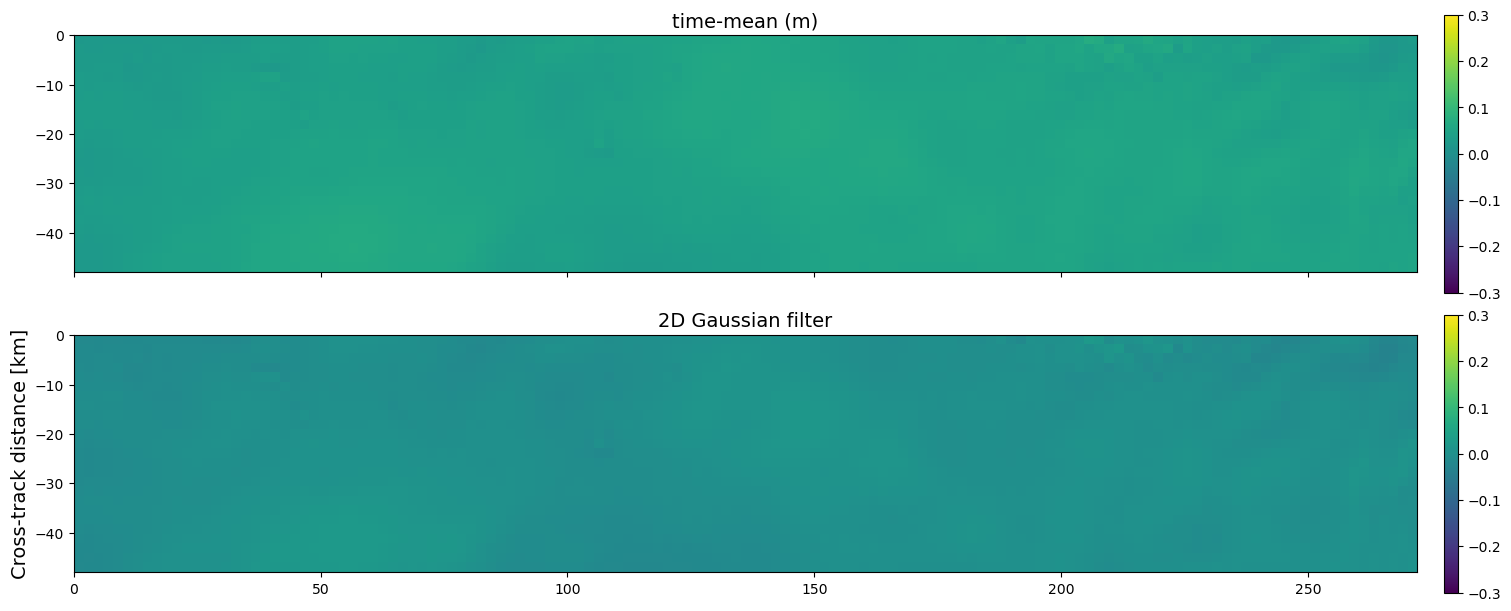

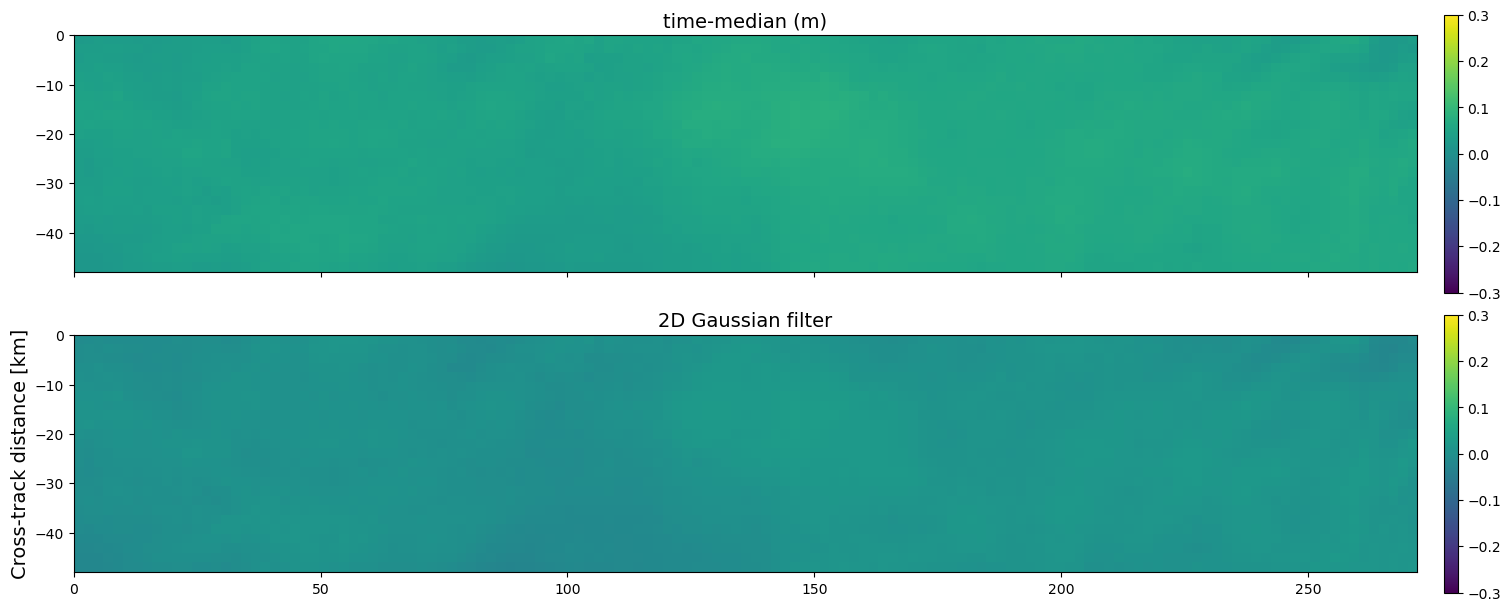

In [15]:
side = 0
fig,ax = plt.subplots(2,1,figsize=(15,6), sharex=True,constrained_layout=True)

cl = ax[0].imshow(ssha_mean[side,:,:].T,cmap = 'viridis',vmin=-0.3,vmax=0.3,\
                  extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl,pad = 0.02)
ax[0].set_title('time-mean (m)',loc = 'center', fontsize=14)

cl3 = ax[1].imshow(ssha_mean_gaussian[side,:,:].T, cmap='viridis', vmin=-0.3, vmax=0.3, 
                    extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl3,pad=0.02)
ax[1].set_ylabel('Cross-track distance [km]',fontsize = 14)
ax[1].set_title('2D Gaussian filter',loc = 'center',fontsize=14)

fig,ax = plt.subplots(2,1,figsize=(15,6), sharex=True,constrained_layout=True)

cl = ax[0].imshow(ssha_med[side,:,:].T,cmap = 'viridis',vmin=-0.3,vmax=0.3,\
                  extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl,pad = 0.02)
ax[0].set_title('time-median (m)',loc = 'center', fontsize=14)

cl3 = ax[1].imshow(ssha_med_gaussian[side,:,:].T, cmap='viridis', vmin=-0.3, vmax=0.3, 
                    extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl3,pad=0.02)
ax[1].set_ylabel('Cross-track distance [km]',fontsize = 14)
ax[1].set_title('2D Gaussian filter',loc = 'center',fontsize=14)

In [16]:
# Gaussian filter 
ssha_arrayanomly_gs = ssha_array - ssha_mean_gaussian[None,:,:,:] # anomalies from high-pass time-mean
sshaspmean_gs = np.nanmean(ssha_arrayanomly_gs,axis=tuple((2,3))) # spatial mean of ssha anomalies (at each time) from high pass time-mean
ssha_arrayanomlysp_gs = ssha_arrayanomly_gs - sshaspmean_gs[:,:,None,None]

/tmp/ipykernel_106543/2609242630.py:3: RuntimeWarning: Mean of empty slice
  sshaspmean_gs = np.nanmean(ssha_arrayanomly_gs,axis=tuple((2,3))) # spatial mean of ssha anomalies (at each time) from high pass time-mean


In [17]:
time_sp_mean  = np.nanmean(ssha_mean,axis = tuple((1,2)))
ssha_mean_sp = ssha_mean - time_sp_mean[:,None,None]# subtract spatial mean of time-mean from time-mean

time_sp_mean_filtered  = np.nanmean(ssha_mean_gaussian,axis = tuple((1,2)))
ssha_mean_filtered_sp = ssha_mean_gaussian - time_sp_mean_filtered[:,None,None]# subtrSWOT_WW3-GLOB-30M_202303_hs.nc.pid39011.ncks.tmpact spatial mean of time-mean from time-mean

time_sp_med  = np.nanmedian(ssha_med,axis = tuple((1,2)))
ssha_med_sp = ssha_mean - time_sp_med[:,None,None]# subtract spatial mean of time-mean from time-mean
time_sp_med_filtered  = np.nanmedian(ssha_med_gaussian,axis = tuple((1,2)))
ssha_med_filtered_sp = ssha_med_gaussian - time_sp_med_filtered[:,None,None]# subtract spatial mean of time-mean from time-mean


In [18]:
lon_new = (lon_strip + 180) % 360 -180
ssha2swath = np.empty(lon_strip.shape)
ssha2swath[:] = np.nan

ssha2swath[:,5:5+25] = ssha_mean_filtered_sp[0,:,:] # time-mean (spatial mean removed)
ssha2swath[:,39:39+25] = ssha_mean_filtered_sp[1,:,:]

In [19]:
ncyc = 24 # cycle 510
ssha2swath_anomsnp = np.empty(lon_strip.shape)
ssha2swath_anomsnp[:] = np.nan
ssha2swath_anomsnp[:,5:5+25] = ssha_arrayanomlysp_gs[ncyc,0,:,:]
ssha2swath_anomsnp[:,39:39+25] = ssha_arrayanomlysp_gs[ncyc,1,:,:]

In [20]:
# select useful stripe only for each of the array
ssha_array_spmean = np.nanmean(ssha_array,axis = tuple((2,3)))
ssha_array_full = ssha_array - ssha_array_spmean[:,:,None,None] # subtract spatial mean to get full signals 

data_array = np.zeros((num_useful_strips, track_length, 25)) # full signal
data_array_gs = np.zeros((num_useful_strips, track_length, 25)) # anomalies from high pass Gaussian time-mean and spatial mean
for strip in range(num_useful_strips):
    cycle_index = good_strips_list[strip,0]
    side_index = good_strips_list[strip,1]
    data_array[strip,:,:] = ssha_array_full[cycle_index, side_index,:,:] # full signal
    data_array_gs[strip,:,:] = ssha_arrayanomlysp_gs[cycle_index, side_index,:,:]

/tmp/ipykernel_106543/258158673.py:2: RuntimeWarning: Mean of empty slice
  ssha_array_spmean = np.nanmean(ssha_array,axis = tuple((2,3)))


In [21]:
def spectrum_compute(data,num_useful_strips,track_length):
    samples = np.arange(num_useful_strips)
    y = 2e3*np.arange(track_length) #distance along track in km (because the resolution is 2kmX2km grid)
    x = 2e3*np.arange(25) #distance across track in km
    data_x = xr.DataArray(data, coords = [samples, y, x], dims = ['sample', 'line', 'pixel'])# convert to dataArray and cm
    window_x = xr.DataArray(np.sqrt(8./3.)*np.sin(np.pi*np.arange(track_length)/track_length)**2, dims = ['line'])
    windowed_per_pixel = data_x*window_x
    pspec_alongtrack = xrft.power_spectrum(windowed_per_pixel, dim = 'line')
    spec = pspec_alongtrack.mean(dim = ['sample','pixel'])
    return spec,pspec_alongtrack
    
def spectrum_compute_1sided(data,num_useful_strips,track_length,ncross=25):
    dx = 2e3
    window = np.sqrt(8./3.)*np.sin(np.pi*np.arange(track_length)/track_length)**2
    window_3d = np.broadcast_to(window.reshape(1, track_length, 1), (num_useful_strips, track_length, ncross))
    windowed = data * window_3d
    amp = np.fft.rfft(windowed,axis=1)# rfft applied to windowed ssh [sample,y/2,x]
    ampsq = dx*(np.abs(amp))**2/track_length
    ampsq_1side = np.empty(ampsq.shape)
    ampsq_1side[:]=np.nan
    ampsq_1side[:,1:,:]=2*ampsq[:,1:,:]
    ampsq_1side[:,0,:] = ampsq[:,0,:]
    spec_1side_ts = np.nanmean(ampsq_1side,axis = 2 )
    spec_1side = np.nanmean(ampsq_1side,axis=tuple([0,2]))
    return spec_1side,spec_1side_ts

In [22]:
# rfft for windowed ssha
dx = 2e3
k = np.fft.rfftfreq(track_length, dx)# rfft wave number cpm
print('shape of ssha ...:',np.shape(data_array_gs),'##',track_length)

shape of ssha ...: (190, 137, 25) ## 137


In [23]:
spec_1side_mean_gs, _ = spectrum_compute_1sided(ssha_mean_filtered_sp,2,track_length)
spec_1side_mean,_ = spectrum_compute_1sided(ssha_mean_sp,2,track_length,ncross=25)

spec_1side_med_gs, _ = spectrum_compute_1sided(ssha_med_filtered_sp,2,track_length)
spec_1side_med,_ = spectrum_compute_1sided(ssha_med_sp,2,track_length,ncross=25)

### Single Sided PSD

In [24]:
specfull1s,_ = spectrum_compute_1sided(data_array,num_useful_strips,track_length)
specanom_gs1s,specanom_gs1s_ts = spectrum_compute_1sided(data_array_gs,num_useful_strips,track_length)
specanom_gs1s_nar,specanom_gs1s_ts_nar = spectrum_compute_1sided(data_array_gs[:,:,3:23],num_useful_strips,track_length,ncross=20)
specanom_gs1s_mid,specanom_gs1s_ts_mid = spectrum_compute_1sided(data_array_gs[:,:,6:18],num_useful_strips,track_length,ncross=12)
data_smooth=0.25*data_array_gs[:,:,5:17]+0.5*data_array_gs[:,:,6:18]+0.25*data_array_gs[:,:,7:19]
data_smooth=0.15*data_array_gs[:,:,4:16]+0.35*data_array_gs[:,:,5:17]+0.35*data_array_gs[:,:,6:18]+0.15*data_array_gs[:,:,7:19]
specanom_gs1s_mis,specanom_gs1s_ts_mis = spectrum_compute_1sided(data_smooth,num_useful_strips,track_length,ncross=12)
print('shape of ssha ...:',num_useful_strips,np.shape(data_array_gs), np.shape(specanom_gs1s),np.shape(specanom_gs1s_ts))

shape of ssha ...: 190 (190, 137, 25) (69,) (190, 69)


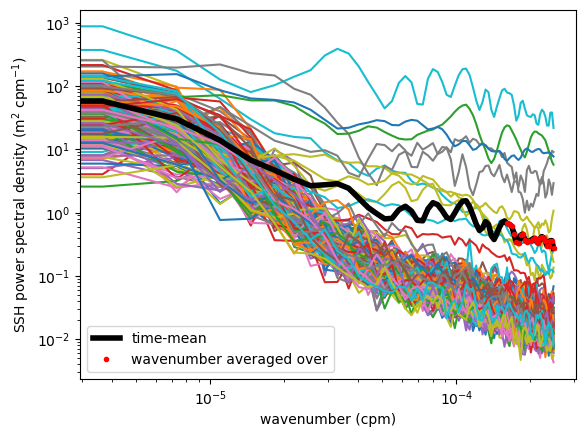

In [25]:
for n in range(specanom_gs1s_ts.shape[0]):
    plt.loglog(k, specanom_gs1s_ts[n,:])#,label=str(n))
plt.loglog(k, specanom_gs1s,color ='k',linewidth=4,label = 'time-mean')
plt.loglog(k[44:], specanom_gs1s[44:],'r.',linewidth=4,label = 'wavenumber averaged over')
plt.xlabel('wavenumber (cpm)')
plt.ylabel('SSH power spectral density (m$^2$ cpm$^{-1}$)')
# plt.xlim((kswot[1],kswot[-1]))
# plt.ylim((1e-2,3e5))
plt.legend()

In [26]:
leftind = np.where(good_strips_list[:,1]==0)[0]
rightind = np.where(good_strips_list[:,1]==1)[0]
cycleft = cycle_list[good_strips_list[leftind,0]]
cycleright = cycle_list[good_strips_list[rightind,0]]

In [29]:
dk=k[1]-k[0]
noiseamp=np.sqrt(np.sum(specanom_gs1s_ts[:,44:],axis=1)*dk)
# convert swot time
tswot=np.zeros(num_useful_strips)


# Open your monthly model file
ds = xr.open_dataset(model_files[0])

print(ds)

print('shape tswot:',np.shape(noiseamp),np.shape(tswot))
for strip in range(num_useful_strips):
    cycle_index = good_strips_list[strip,0]
    side_index = good_strips_list[strip,1]
    tswot[strip]=np.nanmean(time_array[cycle_index,side_index,:])
    
#timeswot = np.squeeze(time_array[good_strips_list,:])# time that when it measures each point 
epoch_time = datetime.datetime(1970, 1, 1)
dt = datetime.datetime(2000, 1, 1, 0, 0)
delta = (dt - epoch_time)

tswot_datetime = np.array([epoch_time + datetime.timedelta(seconds=(t + delta.total_seconds())) for t in tswot])



<xarray.Dataset>
Dimensions:    (latitude: 317, longitude: 720, time: 744)
Coordinates:
  * latitude   (latitude) float32 -78.0 -77.5 -77.0 -76.5 ... 79.0 79.5 80.0
  * longitude  (longitude) float32 -180.0 -179.5 -179.0 ... 178.5 179.0 179.5
  * time       (time) datetime64[ns] 2023-01-01 ... 2023-01-31T23:00:00
Data variables:
    MAPSTA     (latitude, longitude) int16 ...
    crs        |S1 ...
    fp         (time, latitude, longitude) float32 ...
    hs         (time, latitude, longitude) float32 ...
    qkk        (time, latitude, longitude) float32 ...
    skw        (time, latitude, longitude) float32 ...
    uwnd       (time, latitude, longitude) float32 ...
    vwnd       (time, latitude, longitude) float32 ...
Attributes: (12/101)
    WAVEWATCH_III_version_number:     7.14
    WAVEWATCH_III_switches:           NOGRB SCRIP SCRIPNC TRKNC DIST MPI PR3 ...
    SIN4 namelist parameter BETAMAX:  1.62
    title:                            WAVEWATCH-III FORECAST
    netcdf_version: 

In [30]:
# Preallocate
lat_mean = np.zeros(len(good_strips_list))
lon_mean = np.zeros(len(good_strips_list))
tswot = np.zeros(len(good_strips_list))

for i, (cycle_index, side_index) in enumerate(good_strips_list):
    # Compute mean lat/lon (you can use median if you prefer)
    lat_mean[i] = np.nanmean(lat_array[cycle_index, side_index, :, :])
    lon_mean[i] = np.nanmean(lon_array[cycle_index, side_index, :, :])
    tswot[i] = np.nanmean(time_array[cycle_index, side_index, :])

epoch_time = datetime.datetime(1970, 1, 1)
dt = datetime.datetime(2000, 1, 1, 0, 0)
delta = (dt - epoch_time)

tswot_datetime = np.array([
    epoch_time + datetime.timedelta(seconds=(t + delta.total_seconds()))
    for t in tswot
])

# If your model were 0–360 instead, use: np.where(lon_mean < 0, lon_mean + 360, lon_mean)
# But from your ncdump, WW3 longitude = -180..180
lon_mean = np.where(lon_mean > 180, lon_mean - 360, lon_mean)


In [31]:


print(model_files)


[PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc'), PosixPath('/media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202401_hs.nc'), PosixPath('

In [32]:
# Prepare storage
hs_model_all = np.full(len(tswot_datetime), np.nan)
qkk_model_all = np.full(len(tswot_datetime), np.nan)
fp_model_all = np.full(len(tswot_datetime), np.nan)
wnd_model_all = np.full(len(tswot_datetime), np.nan)

# Loop through available model files
for model_file in model_files:
    print(f"Processing {model_file}")
    ds = xr.open_dataset(model_file)
    
    # Extract start and end time of the model file
    tmin = pd.to_datetime(ds.time.values[0])
    tmax = pd.to_datetime(ds.time.values[-1])
    
    # Find which SWOT strips fall into this time range
    idx = np.where((tswot_datetime >= tmin) & (tswot_datetime <= tmax))[0]
    if len(idx) == 0:
        ds.close()
        continue
    
    # Subset SWOT data for this month
    lon_sub = lon_mean[idx]
    lat_sub = lat_mean[idx]
    time_sub = tswot_datetime[idx]
    #print('TEST:',idx,'##',lon_sub,'##',lat_sub,'##',time_sub)
    # Interpolate model data
    # Interpolate WW3 variables at SWOT positions/times
    hs_sub = ds['hs'].interp(longitude=('points', lon_sub),
                             latitude=('points', lat_sub),
                             time=('points', time_sub))
    
    fp_sub = ds['fp'].interp(longitude=('points', lon_sub),
                             latitude=('points', lat_sub),
                             time=('points', time_sub))
    
    qkk_sub = ds['qkk'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))

    wndu = ds['uwnd'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))
    wndv = ds['vwnd'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))

    
    # Store in arrays aligned with SWOT strips
    hs_model_all[idx] = hs_sub.values
    fp_model_all[idx] = fp_sub.values
    qkk_model_all[idx] = qkk_sub.values
    wnd_model_all[idx] = np.sqrt(wndu.values**2+wndv.values**2)
    ds.close()

df = pd.DataFrame({
    "time": tswot_datetime,
    "lat": lat_mean,
    "lon": lon_mean,
    "noiseamp_m": 100 * noiseamp,
    "hs_model_m": hs_model_all,
    "wnd_model_m": wnd_model_all,
    "qkk_model_m": qkk_model_all,
    "fp_model_s-1": fp_model_all
})

#df.to_csv("swot_ww3_colocation_2023_04to07.csv", index=False)


Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202401_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-

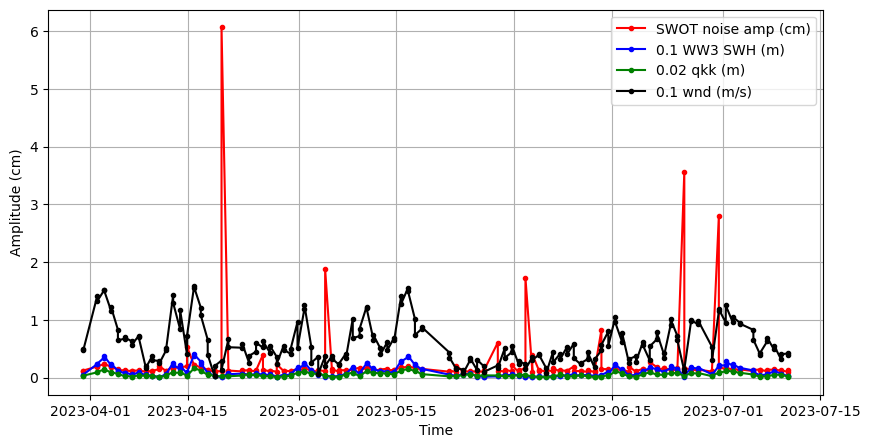

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["time"], df["noiseamp_m"], 'r.-', label="SWOT noise amp (cm)")
plt.plot(df["time"], 0.1*df["hs_model_m"], 'b.-', label="0.1 WW3 SWH (m)")
plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="0.02 qkk (m)")
plt.plot(df["time"], 0.1*df["wnd_model_m"], 'k.-', label="0.1 wnd (m/s)")
#plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="WW3 qkk (m)")
plt.xlabel("Time")
plt.ylabel("Amplitude (cm)")
plt.legend()
plt.grid(True)
plt.show()



In [34]:
seg_length = 20  # along-track pixels (~40 km)
n_cross = 20     # total cross-track pixels
num_seg = track_length // seg_length
num_useful_strips = len(good_strips_list)

# Preallocate arrays for the segments
data_gs_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
lat_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
lon_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
time_seg = np.empty((num_useful_strips, num_seg, seg_length))
tswot_seg = np.empty((num_useful_strips, num_seg))

data_gs_seg[:] = np.nan
lat_seg[:] = np.nan
lon_seg[:] = np.nan
time_seg[:] = np.nan

for strip in range(num_useful_strips):
    cycle_index, side_index = good_strips_list[strip]
    
    for s in range(num_seg):
        start_idx = s * seg_length
        end_idx = start_idx + seg_length
        data_gs_seg[strip, s, :, :] = data_array_gs[strip, start_idx:end_idx, 2:2+n_cross]
        lat_seg[strip, s, :, :] = lat_array[cycle_index, side_index, start_idx:end_idx, 2:2+n_cross]
        lon_seg[strip, s, :, :] = lon_array[cycle_index, side_index, start_idx:end_idx, 2:2+n_cross]
        time_seg[strip, s, :] = time_array[cycle_index, side_index, start_idx:end_idx]

        tswot_seg[strip,s] = np.nanmean(time_seg[strip, s, :])



shape: (1140, 20, 20)


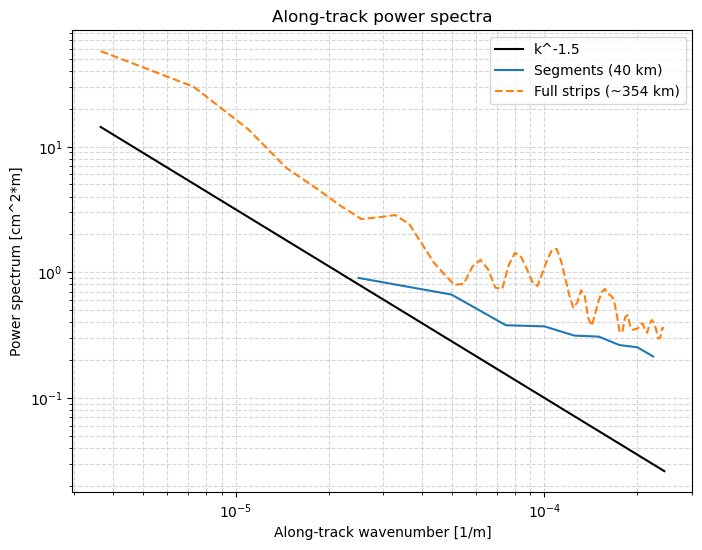

In [35]:
# Flatten the segments along the strip and segment dimensions
num_segments_total = num_useful_strips * num_seg
data_gs_seg_flat = data_gs_seg.reshape(num_segments_total, seg_length, n_cross)
print('shape:',np.shape(data_gs_seg_flat))


# detrend along the along-track axis (axis=1)
data_gs_seg_flat_detrended = detrend(data_gs_seg_flat, axis=1, type='linear')


# Compute 1-sided FFT for the segments using your existing function
specanom_gs_seg1s, specanom_gs_seg1s_ts = spectrum_compute_1sided(
    data_gs_seg_flat_detrended, num_segments_total, seg_length, ncross=n_cross
)

# compute wavenumber axis
# Wavenumber for full strips
k_full = np.fft.rfftfreq(track_length, d=2e3)  # track_length = 177, spacing = 2 km

# Wavenumber for segments
k_seg = np.fft.rfftfreq(seg_length, d=2e3)     # seg_length = 20
#print('full:',k_full[44:])
#print(k_seg[5:])

plt.figure(figsize=(8,6))
plt.loglog(k_full[1:-1], 0.1/(k_full[1:-1]/1E-4)**1.5, c='k',label='k^-1.5', linestyle='-')
plt.loglog(k_seg[1:-1], specanom_gs_seg1s[1:-1], label='Segments (40 km)')
plt.loglog(k_full[1:-1], specanom_gs1s[1:-1], label='Full strips (~354 km)', linestyle='--')
plt.xlabel('Along-track wavenumber [1/m]')
plt.ylabel('Power spectrum [cm^2*m]')
plt.title('Along-track power spectra')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.show()


In [36]:
# Assume dk is already defined (from np.fft.rfftfreq)
dk_seg=k_seg[1]-k_seg[0]
noiseamp_seg = np.sqrt(np.sum(specanom_gs_seg1s_ts[:, 5:], axis=1) * dk_seg)
noiseamp_seg = noiseamp_seg.reshape(num_useful_strips, num_seg)


In [37]:
# ----------------------------
# 1. Compute segment-mean lat/lon/time
# ----------------------------

# Preallocate arrays
lat_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
lon_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
tswot_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
uncert_seg_var = np.full((num_useful_strips, num_seg), np.nan)

print('size:',np.shape(uncert_array),np.shape(lat_array),np.shape(lat_strip))

for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    lat_strip = lat_array[cycle_idx, side_idx, :, :]
    lon_strip = lon_array[cycle_idx, side_idx, :, :]
    time_strip = time_array[cycle_idx, side_idx, :]
    uncert_strip=uncert_array[cycle_idx, side_idx, :,:]
    n_along = lat_strip.shape[0]
    seg_edges = np.linspace(0, n_along, num_seg + 1, dtype=int)
    
    for s in range(num_seg):
        idx_start = seg_edges[s]
        idx_end = seg_edges[s + 1]
        
        # Cross-track mean
        lat_seg_mean[i, s] = np.nanmean(lat_strip[idx_start:idx_end, :])
        lon_seg_mean[i, s] = np.nanmean(lon_strip[idx_start:idx_end, :])
        tswot_seg_mean[i, s] = np.nanmean(time_strip[idx_start:idx_end])
        uncert_seg_var[i, s] = np.nanmean((uncert_strip[idx_start:idx_end,:].flatten())**2)
# Flatten to 1D arrays for DataFrame and interpolation
lat_seg_mean_flat = lat_seg_mean.flatten()
lon_seg_mean_flat = lon_seg_mean.flatten()
tswot_seg_mean_flat = tswot_seg_mean.flatten()
noiseamp_seg_flat = noiseamp_seg.flatten()  # already matches shape
uncert_seg_flat = uncert_seg_var.flatten()  # already matches shape

num_segments_total = lat_seg_mean_flat.size

# Convert to datetime
epoch_time = datetime.datetime(1970, 1, 1)
dt_ref = datetime.datetime(2000, 1, 1)
delta = (dt_ref - epoch_time).total_seconds()

tswot_seg_datetime = np.array([
    epoch_time + datetime.timedelta(seconds=(t + delta))
    for t in tswot_seg_mean_flat
])

# Fix longitudes if necessary
lon_seg_mean_flat = np.where(lon_seg_mean_flat > 180, lon_seg_mean_flat - 360, lon_seg_mean_flat)

# ----------------------------
# 2. Interpolate WW3 model variables
# ----------------------------

hs_model_seg = np.full(num_segments_total, np.nan)
qkk_model_seg = np.full(num_segments_total, np.nan)
wnd_model_seg = np.full(num_segments_total, np.nan)
fp_model_seg = np.full(num_segments_total, np.nan)

for model_file in model_files:
    print(f"Processing {model_file}")
    ds = xr.open_dataset(model_file)
    
    tmin = pd.to_datetime(ds.time.values[0])
    tmax = pd.to_datetime(ds.time.values[-1])
    
    tswot_seg_pd = pd.to_datetime(tswot_seg_datetime)
    idx = np.where((tswot_seg_pd >= tmin) & (tswot_seg_pd <= tmax))[0]
    
    if len(idx) == 0:
        ds.close()
        continue
    
    hs_sub = ds['hs'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    fp_sub = ds['fp'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    qkk_sub = ds['qkk'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndu = ds['uwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndv = ds['vwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    
    hs_model_seg[idx] = hs_sub.values
    fp_model_seg[idx] = fp_sub.values
    qkk_model_seg[idx] = qkk_sub.values
    wnd_model_seg[idx] = np.sqrt(wndu.values**2+wndv.values**2)
    
    ds.close()

# ----------------------------
# 3. Build DataFrame
# ----------------------------

df_seg = pd.DataFrame({
    "strip_segment_idx": np.repeat(np.arange(num_useful_strips), num_seg),
    "segment_idx": np.tile(np.arange(num_seg), num_useful_strips),
    "lat": lat_seg_mean_flat,
    "lon": lon_seg_mean_flat,
    "time": tswot_seg_datetime,
    "noiseamp_m": noiseamp_seg_flat,
    "uncert": np.sqrt(uncert_seg_flat),
    "hs_model_m": hs_model_seg,
    "qkk_model_m": qkk_model_seg,
    "wnd_model_m": wnd_model_seg,
    "fp_model_s-1": fp_model_seg
})

# ----------------------------
# 4. Save CSV
# ----------------------------
#df_seg.to_csv("swot_ww3_colocation_segments_segment_avg.csv", index=False)
#print(f"Saved CSV with {num_segments_total} segment points.")


size: (100, 2, 137, 20) (100, 2, 137, 25) (137, 69)
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc
Processing /media/ardhuin/FabLinux/WW3-CCI/CCI_WW3-GLOB-30M_202401_hs.nc

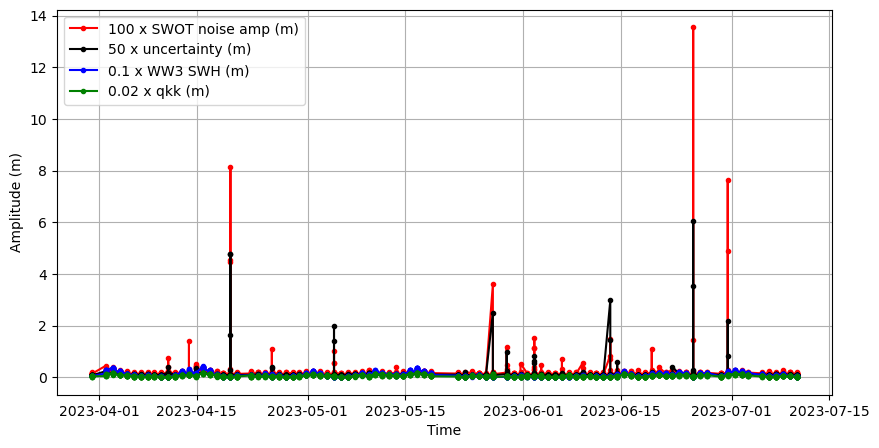

In [38]:


plt.figure(figsize=(10,5))
plt.plot(df_seg["time"], 100*df_seg["noiseamp_m"], 'r.-', label="100 x SWOT noise amp (m)")
plt.plot(df_seg["time"], 50*df_seg["uncert"], 'k.-', label="50 x uncertainty (m)")
plt.plot(df_seg["time"], 0.1*df_seg["hs_model_m"], 'b.-', label="0.1 x WW3 SWH (m)")
plt.plot(df_seg["time"], 0.02*df_seg["qkk_model_m"], 'g.-', label="0.02 x qkk (m)")
#plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="WW3 qkk (m)")
plt.xlabel("Time")
plt.ylabel("Amplitude (m)")
plt.legend()
plt.grid(True)
plt.show()


In [39]:
dx=2000;dy=2000
X=np.arange(20)*dx/1000;
m=1;n=1;i1=0;i2=21;j1=0;j2=21

noise_10k = np.full((num_useful_strips, num_seg), np.nan)
noise_10l = np.full((num_useful_strips, num_seg), np.nan)
noise_10m = np.full((num_useful_strips, num_seg), np.nan)
noise_10n = np.full((num_useful_strips, num_seg), np.nan)

EtameanL=np.zeros((20,20))
EtameanR=np.zeros((20,20))
nmeanL=0
nmeanR=0
for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    
    for s in range(num_seg):
        mybox=data_gs_seg[i, s, :, :]
        flbox=mybox*0+1
        myboh=mybox
        (Eta,Etb,ang,angstd,coh,crosr,phases,ky2,kx2,dky,dkx,detrenda,detrendb,nspec)=FFT2D_two_arrays_nm_detrend_flag(mybox,myboh,flbox,dy,dx,n,m,detrend='quadratic') #,ffill='none')
        if (i==0 & s==0):
            ind1 = np.where((abs(kx2) < 1.5E-4) & (abs(ky2) > 0.00012))[0]
            ind2 = np.where((abs(kx2) > 2.4E-4) & (abs(ky2) > 0.00012))[0]
            ind3 = np.where((abs(kx2) < 0.00012) & (abs(ky2) < 0.00012))[0]
            ind4 = np.where((abs(kx2) > 1.2E-4) & (abs(ky2) > 1.2E-4) &(abs(kx2) < 2.4E-4) & (abs(ky2) < 2.4E-4))[0]
            #ind4 = np.where((abs(kx2) > 0.25E-4) & (abs(ky2) > 0.25E-4) &(abs(kx2) < 2.4E-4) & (abs(ky2) < 2.4E-4))[0]
        if not np.isnan(Eta[0,0]):
            if side_idx==0:
                EtameanL=EtameanL+Eta
                nmeanL=nmeanL+1
            else:
                EtameanR=EtameanR+Eta
                nmeanR=nmeanR+1
                
            
        varm=np.sum(Eta[ind1]*dkx*dky)
        noise_10k[i,s]=100*np.sqrt(varm)
        varm=np.sum(Eta[ind2]*dkx*dky)
        noise_10l[i,s]=100*np.sqrt(varm)
        varm=np.sum(Eta[ind3]*dkx*dky)
        noise_10m[i,s]=100*np.sqrt(varm)
        varm=np.sum(Eta[ind4]*dkx*dky)
        noise_10n[i,s]=100*np.sqrt(varm)
# Flatten to 1D arrays for DataFrame and interpolation
noise_10k_flat = noise_10k.flatten()
noise_10l_flat = noise_10l.flatten()
noise_10m_flat = noise_10m.flatten()
noise_10n_flat = noise_10n.flatten()



/home/ardhuin/miniconda3/envs/OPTOOLS_clone/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/ardhuin/PUBLI/2025_Eddie/scripts/../src/spectral_analysis_functions.py:672: RuntimeWarning: invalid value encountered in divide
  phases[:,:,m]=phases[:,:,m]/phase;


In [40]:

hemiNS=['A','N','S']
hemiWE=['A','E','W']
lightcmap = cmocean.tools.lighten(cmo.ice, 1)
lightcmap2 = cmocean.tools.lighten(cmo.ice_r, 1)

dx=2000;dy=2000
X=np.arange(20)*dx/1000;
m=1;n=1;i1=0;i2=21;j1=0;j2=21
dBE=10;dBE2=10;amax=0.2;fs1=20; # font size
fshrink=0.8;

indsub0=0
Y=(np.arange(20)+indsub0)*dy/1000 
strip=1
s=4

latc=lat_seg_mean[strip, s]; latcr=np.round(latc*2)/2; latcs=f'{abs(latc):3.2f}'+hemiNS[int(np.sign(latc))]
lonc=lon_seg_mean[strip, s]; loncr=np.round(lonc*2)/2; loncs=f'{abs(lonc):3.2f}'+hemiWE[int(np.sign(lonc))]


mybox=data_gs_seg[strip, s, :, :]
flbox=mybox*0+1
myboh=mybox
(Eta,Etb,ang,angstd,coh,crosr,phases,ky2,kx2,dky,dkx,detrenda,detrendb,nspec)=FFT2D_two_arrays_nm_detrend_flag(mybox,myboh,flbox,dy,dx,n,m,detrend='quadratic') #,ffill='none')


In [41]:
# --- Initialize arrays ---
noise_250_AT = np.full((num_useful_strips, num_seg), np.nan)
noise_250_CT = np.full((num_useful_strips, num_seg), np.nan)

noise_250_AT_f = np.full((num_useful_strips, num_seg), np.nan)
noise_250_CT_f = np.full((num_useful_strips, num_seg), np.nan)

noise_250_AT_n = np.full((num_useful_strips, num_seg), np.nan)
noise_250_CT_n = np.full((num_useful_strips, num_seg), np.nan)

hs_model_2D = np.full((num_useful_strips, num_seg), np.nan)
qkk_model_2D = np.full((num_useful_strips, num_seg), np.nan)
wnd_model_2D = np.full((num_useful_strips, num_seg), np.nan)

# Arrays to store the indices of the minimum value for each segment
min_indices_fy = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
min_indices_fx = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
max_indices_fy = np.full((num_useful_strips, num_seg), np.nan, dtype=int)
max_indices_fx = np.full((num_useful_strips, num_seg), np.nan, dtype=int)

# --- Storage for SSH filename and indices ---
ssh_filenames = np.empty((num_useful_strips), dtype=object)

i1_indices = np.full((num_useful_strips, num_seg), np.nan)
i2_indices = np.full((num_useful_strips, num_seg), np.nan)
j1_indices = np.full((num_useful_strips, num_seg), np.nan)
j2_indices = np.full((num_useful_strips, num_seg), np.nan)
track_angle = np.full((num_useful_strips, num_seg), np.nan)
uncertainty = np.full((num_useful_strips, num_seg), np.nan)
uncertainty_std = np.full((num_useful_strips, num_seg), np.nan)
uncertainty_near= np.full((num_useful_strips, num_seg), np.nan)
uncertainty_farr= np.full((num_useful_strips, num_seg), np.nan)
uncertainty_std= np.full((num_useful_strips, num_seg), np.nan)


# --- Initialize the Dataset ---
# We'll fill Efxfy as we go

Efxfy_data = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_unce = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_near = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
Efxfy_farr = np.full((num_useful_strips, num_seg, nfy, nfx), np.nan)
time_arr = np.empty((num_useful_strips, num_seg), dtype="datetime64[ns]")
side_arr=np.full((num_useful_strips), np.nan)
 
ds_seg = xr.Dataset(
    coords={
        "strip_id": np.arange(num_useful_strips),
        "segment_id": np.arange(num_seg),
        "fy": np.arange(nfy),
        "fx": np.arange(nfx),
    }
)

first=0


# --- Main loop ---
for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
  if good_strips_list[i,1]==0 :
    side_arr[i]=0
  else: 
    side_arr[i]=1
      
  cycle = f'{int(cycle_list[cycle_idx]):03d}'
  filename = str(swot_spectra_folder)+specfolder+'/SWOT_L2_LR_WIND_WAVE_' + cycle + '_'+spass+'_202*_v2.1_beta.nc'
  print('i, filename:',i,filename)
  file_listnc = sorted(glob.glob(filename))
  print(len(file_listnc),num_seg)

  if (len(file_listnc) >0):
    #print('file test:', file_listnc[0])
    L3Snc = xr.open_dataset(file_listnc[0])
    filetest=file_listnc[0].replace(specfolder, "Unsmoothed").replace("WIND_WAVE", "SSH_Unsmoothed").replace("v2.1_beta", "PGD0_01").replace("FabLinux","FabBack")
    ssh_filenames[i]=Path(ssh_file = (lambda f: f if os.path.exists(f) else None)(filetest)).name

    if (ssh_filenames[i] == None):
       filetest=file_listnc[0].replace(specfolder, "Unsmoothed").replace("WIND_WAVE", "SSH_Unsmoothed").replace("v2.1_beta", "PGD0_02").replace("FabLinux","FabBack")
       ssh_filenames[i]=Path(ssh_file = (lambda f: f if os.path.exists(f) else None)(filetest)).name

    if (ssh_filenames[i] == None):
       filetest=file_listnc[0].replace(specfolder, "Unsmoothed").replace("WIND_WAVE", "SSH_Unsmoothed").replace("v2.1_beta", "PID0_01").replace("FabLinux","FabBack")
       ssh_filenames[i]=Path(ssh_file = (lambda f: f if os.path.exists(f) else None)(filetest)).name
    temp=ssh_filenames[i]      
    print('file:', ssh_filenames[i], i, cycle_idx, side_idx)
    #print('filetest:', filetest,'##', ssh_filenames[i])
    lat_spec = L3Snc.latitude.values
    lon_spec = L3Snc.longitude.values
    urms  = L3Snc.ssh_uncertainty.values
    ustd  = L3Snc.ssh_uncertainty_std.values
    lon_spec = np.where(lon_spec > 180, lon_spec - 360, lon_spec)

    n_along = lat_strip.shape[0]
    seg_edges = np.linspace(0, n_along, num_seg + 1, dtype=int)

    for s in range(num_seg):
        index_1d = i *num_seg + s
        hs_model_2D[i,s]=hs_model_seg[index_1d]
        qkk_model_2D[i,s]=qkk_model_seg[index_1d]
        wnd_model_2D[i,s]=wnd_model_seg[index_1d]
        

        time_arr[i,s] = np.datetime64(df_seg["time"].iloc[index_1d])
        lat0 = lat_seg_mean[i, s]
        clat = np.cos(lat0 * np.pi / 180)
        lon0 = lon_seg_mean[i, s]
        if lon0 > 180:
            lon0 -= 360
        #if (s==0 & i==0): 
        filter_PTR=L3Snc.filter_PTR.copy()
        filter_OBP=L3Snc.filter_OBP.copy()
        dist2 = (lat_spec - lat0)**2 + (lon_spec - lon0)**2 * clat**2
        ibox = np.nanargmin(dist2)
# Adds along-track averaging in the case of 20 km overlapping boxes, in order to cover 40 km along-track in the average
        if specres=="SR3":  # in this case we also define near-range and far-range variables
            uncertainty[i,s] = np.sqrt((L3Snc.ssh_uncertainty[ibox]**2+L3Snc.ssh_uncertainty[ibox+6]**2+L3Snc.ssh_uncertainty[ibox-6]**2)/3)
            uncertainty_std[i,s] = np.sqrt((L3Snc.ssh_uncertainty_std[ibox]**2+L3Snc.ssh_uncertainty_std[ibox+6]**2+L3Snc.ssh_uncertainty_std[ibox-6]**2)/3)
            Etas = (L3Snc.Efxfy_SWOT[ibox]+L3Snc.Efxfy_SWOT[ibox+6]+L3Snc.Efxfy_SWOT[ibox-6])/3
            Etau = (L3Snc.Efxfy_uncertainty[ibox]+L3Snc.Efxfy_SWOT[ibox+6]+L3Snc.Efxfy_SWOT[ibox-6])/3
            nbox=ibox+1-2*(ibox % 6)//3
            fbox=ibox-1+2*(ibox % 6)//3

            Etaf = (L3Snc.Efxfy_SWOT[fbox]+L3Snc.Efxfy_SWOT[fbox+6]+L3Snc.Efxfy_SWOT[fbox-6])/3
            uncertainty_farr[i,s] = np.sqrt((L3Snc.ssh_uncertainty[fbox]**2+L3Snc.ssh_uncertainty[fbox+6]**2+L3Snc.ssh_uncertainty[fbox-6]**2)/3)
            Etan = (L3Snc.Efxfy_SWOT[nbox]+L3Snc.Efxfy_SWOT[nbox+6]+L3Snc.Efxfy_SWOT[nbox-6])/3
            uncertainty_near[i,s] = np.sqrt((L3Snc.ssh_uncertainty[nbox]**2+L3Snc.ssh_uncertainty[nbox+6]**2+L3Snc.ssh_uncertainty[nbox-6]**2)/3)
        else:
            uncertainty[i,s] = L3Snc.ssh_uncertainty[ibox]
            uncertainty_std[i,s] = L3Snc.ssh_uncertainty_std[ibox]
            Etas = L3Snc.Efxfy_SWOT[ibox]
            Etau = L3Snc.Efxfy_uncertainty[ibox]
            nbox=ibox  # use same box if not 20 km boxes 
            fbox=ibox  #

            Etaf = Etas
            uncertainty_farr[i,s] = uncertainty[i,s] 
            Etan = Etas
            uncertainty_near[i,s] = uncertainty[i,s] 
            
        # we apply the PTR to flatten the spectrum ... 
        #print('ibox :',np.nanmin(dist2),ibox,ibox % 6,L3Snc.box_indx[ibox].values,'near:',nbox,fbox)

        Etas = Etas*L3Snc.filter_PTR
        Etaf = Etaf*L3Snc.filter_PTR
        Etan = Etan*L3Snc.filter_PTR

        kx2s = L3Snc.fx2D
        ky2s = L3Snc.fy2D
        j1_indices[i,s] = L3Snc['boxindices'][ibox,0].values
        j2_indices[i,s] = L3Snc['boxindices'][ibox,1].values  
        i1_indices[i,s] = L3Snc['boxindices'][ibox,2].values
        i2_indices[i,s] = L3Snc['boxindices'][ibox,3].values

        track_angle[i,s]=L3Snc['track_angle'][ibox].values

        if (first==0):
            knorm=np.sqrt(kx2s**2+ky2s**2)
            # Mask the center region (where knorm <= 5e-4)
            mask = (knorm > 5e-4) & (knorm < 1e-3)
            
        if i == 0 and s == 0:
            dkxs = kx2s[0, 1] - kx2s[0, 0]
            dkys = ky2s[1, 0] - ky2s[0, 0]
            ind1 = np.where((abs(kx2s) < 1.5E-4) & (abs(ky2s) > 0.00012))
            ind2 = np.where((abs(kx2s) > 2.4E-4) & (abs(ky2s) > 0.00012))

        if not np.isnan(Etas[0, 0]):
            Efxfy_data[i, s, :, :] = Etas/L3Snc.filter_PTR  # back to the original spectrum ... 
            Efxfy_unce[i, s, :, :] = Etau
            Efxfy_near[i, s, :, :] = Etan/L3Snc.filter_PTR
            Efxfy_farr[i, s, :, :] = Etaf/L3Snc.filter_PTR


            # Apply the mask to Etas (set masked values to np.nan)
            Etas_masked = Etas.where(mask)

            # Flatten the masked array ignoring NaNs
            Etas_flat = Etas_masked.values.flatten()  # if Etas is xarray.DataArray
            Etas_flat = Etas_flat[~np.isnan(Etas_flat)]  # remove NaNs
            p10 = np.percentile(Etas_flat, 2)

            
# Find the index of the minimum value in the masked array
# (use np.nanargmin to ignore NaN values)
            min_idx_flat = np.nanargmin(Etas_masked)
            min_idx = np.unravel_index(min_idx_flat, Etas.shape)
            max_idx_flat = np.nanargmax(Etas_masked)
            max_idx = np.unravel_index(max_idx_flat, Etas.shape)

# Store the indices
            min_indices_fy[i, s] = min_idx[0]
            min_indices_fx[i, s] = min_idx[1]            
            #min_idx = np.unravel_index(np.nanargmin(Etas), Etas.shape)

            max_indices_fy[i, s] = max_idx[0]
            max_indices_fx[i, s] = max_idx[1]  
            ##### Now use a fixed index ... 
            
            max_indices_fy[i, s] = yCTind
            max_indices_fx[i, s] = xCTind
            fy_max = kx2s[int(max_indices_fy[i, s]),0]
            fx_max = kx2s[0,int(max_indices_fx[i, s])]
            #print('Fixed:',fx_max*1E3,fy_max*1E3)
            #max_idx = np.unravel_index(np.nanargmax(Etas), Etas.shape)

            # used a fixed spectral index... 
            min_indices_fy[i, s] = yATind
            min_indices_fx[i, s] = xATind
            noise_250_AT[i, s] = Etas[min_indices_fy[i, s],min_indices_fx[i, s]]
            noise_250_CT[i, s] = Etas[max_indices_fy[i, s] ,max_indices_fx[i, s] ]
            
            noise_250_AT_f[i, s] = Etaf[min_idx[0],min_idx[1]] 
            noise_250_CT_f[i, s] = Etaf[max_idx[0],max_idx[1]] 
            #print('TEST:',varm.values,dkxs.values,dkys.values,noise_250l_f[i, s])

            noise_250_AT_n[i, s] = Etan[min_idx[0],min_idx[1]] 
            noise_250_CT_n[i, s] = Etan[max_idx[0],max_idx[1]] 


# --- Add variables to the Dataset ---
ds_seg["time"] = (["strip_id", "segment_id"],time_arr)
ds_seg["lon"] = (["strip_id", "segment_id"],lon_seg_mean)
ds_seg["lat"] = (["strip_id", "segment_id"],lat_seg_mean)
ds_seg["lat"] = (["strip_id", "segment_id"],lat_seg_mean)
ds_seg["side"] = (["strip_id"],side_arr)
ds_seg["hs_model"] = (["strip_id", "segment_id"],hs_model_2D)
ds_seg["qkk_model"] = (["strip_id", "segment_id"],qkk_model_2D)
ds_seg["wnd_model"] = (["strip_id", "segment_id"],wnd_model_2D)
ds_seg["ssh_filenames"] = (["strip_id"],ssh_filenames)
ds_seg["j1_indices"] = (["strip_id", "segment_id"],j1_indices)
ds_seg["j2_indices"] = (["strip_id", "segment_id"],j2_indices)
ds_seg["i1_indices"] = (["strip_id", "segment_id"],i1_indices)
ds_seg["i2_indices"] = (["strip_id", "segment_id"],i2_indices)
ds_seg["track_angle"] = (["strip_id", "segment_id"],track_angle)

ds_seg["filter_PTR"] = (["fy", "fx"], filter_PTR.values)
ds_seg["filter_OBP"] = (["fy", "fx"], filter_OBP.values)


ds_seg["Efxfy"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_data)  
ds_seg["Efxfy_u"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_unce)
ds_seg["Efxfy_f"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_farr)
ds_seg["Efxfy_n"] = (["strip_id", "segment_id", "fy", "fx"], Efxfy_near)
ds_seg["fx2D"] = (["fy", "fx"], kx2s.values)
ds_seg["fy2D"] = (["fy", "fx"], ky2s.values)
ds_seg["track_angle"] = (["strip_id", "segment_id"], track_angle)
ds_seg["noise_250_AT"] = (["strip_id", "segment_id"], noise_250_AT)
ds_seg["noise_250_CT"] = (["strip_id", "segment_id"], noise_250_CT)
ds_seg["noise_250_AT_f"] = (["strip_id", "segment_id"], noise_250_AT_f)
ds_seg["noise_250_CT_f"] = (["strip_id", "segment_id"], noise_250_CT_f)
ds_seg["noise_250_AT_n"] = (["strip_id", "segment_id"], noise_250_AT_n)
ds_seg["noise_250_CT_n"] = (["strip_id", "segment_id"], noise_250_CT_n)

ds_seg["min_indices_fy"] = (["strip_id", "segment_id"], min_indices_fy)
ds_seg["min_indices_fx"] = (["strip_id", "segment_id"], min_indices_fx)
ds_seg["max_indices_fy"] = (["strip_id", "segment_id"], max_indices_fy)
ds_seg["max_indices_fx"] = (["strip_id", "segment_id"], max_indices_fx)

ds_seg["uncert"] = (["strip_id", "segment_id"], np.sqrt(uncert_seg_var))
ds_seg["uncertainty"] = (["strip_id", "segment_id"], uncertainty)
ds_seg["uncertainty_std"] = (["strip_id", "segment_id"], uncertainty_std)
ds_seg["uncertainty_near"] = (["strip_id", "segment_id"], uncertainty_near)
ds_seg["uncertainty_far"] = (["strip_id", "segment_id"], uncertainty_farr)

# --- Add attributes ---
ds_seg["Efxfy"].attrs["long_name"] = "2D Wave Spectra"
ds_seg["Efxfy"].attrs["units"] = "m^2/Hz/deg"
ds_seg["noise_250_AT"].attrs["long_name"] = "Noise level (E_AT)"
ds_seg["noise_250_AT"].attrs["units"] = "m4"
ds_seg["noise_250_CT"].attrs["long_name"] = "Noise level (E_CT)"
ds_seg["noise_250_CT"].attrs["units"] = "m4"
ds_seg["noise_250_AT_f"].attrs["long_name"] = "Noise level far  (E_AT)"
ds_seg["noise_250_AT_f"].attrs["units"] = "m4"
ds_seg["noise_250_CT_f"].attrs["long_name"] = "Noise level far  (E_CT)"
ds_seg["noise_250_CT_f"].attrs["units"] = "m4"
ds_seg["noise_250_AT_n"].attrs["long_name"] = "Noise level near (E_AT)"
ds_seg["noise_250_AT_n"].attrs["units"] = "m4"
ds_seg["noise_250_CT_n"].attrs["long_name"] = "Noise level near (E_CT)"
ds_seg["noise_250_CT_n"].attrs["units"] = "m4"
ds_seg["min_indices_fy"].attrs["long_name"] = "fy index of minimum value"
ds_seg["min_indices_fx"].attrs["long_name"] = "fx index of minimum value"
ds_seg["max_indices_fy"].attrs["long_name"] = "fy index of maximum value"
ds_seg["max_indices_fx"].attrs["long_name"] = "fx index of maximum value"

# --- Print the Dataset ---
print(ds_seg)
# Save to NetCDF
ds_seg.to_netcdf('SWOT_segments'+ana_tag+'.nc')

i, filename: 0 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_476_003_202*_v2.1_beta.nc
0 6
i, filename: 1 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_476_003_202*_v2.1_beta.nc
0 6
i, filename: 2 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_478_003_202*_v2.1_beta.nc
0 6
i, filename: 3 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_478_003_202*_v2.1_beta.nc
0 6
i, filename: 4 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc
0 6
i, filename: 5 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_479_003_202*_v2.1_beta.nc
0 6
i, filename: 6 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_480_003_202*_v2.1_beta.nc
0 6
i, filename: 7 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_480_003_202*_v2.1_beta.nc
0 6
i, filename: 8 /media/ardhuin/FabLinux/SWOT2L2_D_WindWave_SR3/SWOT_L2_LR_WIND_WAVE_481_003_202*_

/home/ardhuin/miniconda3/envs/OPTOOLS_clone/lib/python3.9/site-packages/numpy/core/numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


NameError: name 'filter_PTR' is not defined

In [46]:
nadirOK=0
# SKIP this cell and the next if you do not have the nadir data for Qkk estimation ... 
if nadirOK==1:
  swh_rms_nadir_1 = np.full((num_useful_strips, num_seg), np.nan)
  swh_rms_nadir_2 = np.full((num_useful_strips, num_seg), np.nan)
  swh_rms_nadir_3 = np.full((num_useful_strips, num_seg), np.nan)
  swh_nadir_1 = np.full((num_useful_strips, num_seg), np.nan)
  swh_nadir_2 = np.full((num_useful_strips, num_seg), np.nan)
  swh_nadir_3 = np.full((num_useful_strips, num_seg), np.nan)

# --- Main loop ---
  for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    filessh=ds_seg["ssh_filenames"][i].values
    print(filessh) 
    # Split by '_'
    parts = str(filessh).split('_')
    part1=parts[0].replace("Unsmoothed", "Nadir_GDR")
    part2 = parts[0].replace("Unsmoothed", "Nadir_CCI")
    # Replace only the last occurrence of "SWOT"
    part2 = part2.rsplit("SWOT", 1)
    part2 = "ESACCI-SEASTATE-L2P-SWH-SWOT-".join(part2)
    filegdr=part1+'_GPN_2PfP'+parts[5]+'_'+parts[6]+'_'+parts[7].replace("T","_")+'_'+parts[8].replace("T","_")+'.nc' 
    fileCCI=part2+parts[7]+'-fv01.nc' 
    #print(fileCCI)
    if os.path.exists(filegdr):
        ds_gdr = xr.open_dataset(filegdr,group='data_01') 
        ds_ku = xr.open_dataset(filegdr, group='data_01/ku')

        for s in range(num_seg):
            lon=ds_seg["lon"][i,s].values
            lat=ds_seg["lat"][i,s].values
            latgdr = ds_gdr['latitude'].values
            lat_min, lat_max = lat - 0.5, lat + 0.5
            # Find indices where latitude is within the range
            indices = np.where((latgdr >= lat_min) & (latgdr <= lat_max))[0]
            swh_nadir_1[i,s]=np.nanmedian(ds_ku['swh_ocean'][indices].values)
            rms=np.nanmedian(ds_ku['swh_ocean_rms'][indices].values*ds_ku['swh_ocean'][indices].values)
            swh_rms_nadir_1[i,s]=rms/swh_nadir_1[i,s]
            swh_nadir_2[i,s]=np.nanmedian(ds_ku['swh_adaptive'][indices].values)
            rms=np.nanmedian(ds_ku['swh_adaptive_rms'][indices].values*ds_ku['swh_adaptive'][indices].values)
            swh_rms_nadir_2[i,s]=rms/swh_nadir_2[i,s]

    if os.path.exists(fileCCI):
        ds_cci = xr.open_dataset(fileCCI) 
        
        for s in range(num_seg):
            lon=ds_seg["lon"][i,s].values
            lat=ds_seg["lat"][i,s].values
            latgdr = ds_gdr['latitude'].values
            lat_min, lat_max = lat - 0.2, lat + 0.2
            # Find indices where latitude is within the range
            indices = np.where((latgdr >= lat_min) & (latgdr <= lat_max))[0]
            swh_nadir_3[i,s]=np.nanmedian(ds_cci['swh'][indices].values)
            rms=np.nanmedian(ds_cci['swh_rms'][indices].values*ds_cci['swh'][indices].values)
            swh_rms_nadir_3[i,s]=rms/swh_nadir_3[i,s]
            #print(i,s,lat,indices[0],indices[-1],swh_nadir_3[i,s],swh_rms_nadir_3[i,s])


In [47]:
if nadirOK==1:
  segs=np.array([0,1,2,3,4,5,6,7])
  X=ds_seg["qkk_model"][:,segs].values.flatten()
  X1=swh_nadir_1[:,segs].flatten()
  Y1=swh_rms_nadir_1[:,segs].flatten()/np.sqrt(swh_nadir_1[:,segs].flatten())
  X2=swh_nadir_2[:,segs].flatten()
  Y2=swh_rms_nadir_2[:,segs].flatten()/np.sqrt(swh_nadir_2[:,segs].flatten())
  X3=swh_nadir_3[:,segs].flatten()
  Y3=swh_rms_nadir_3[:,segs].flatten()/np.sqrt(swh_nadir_3[:,segs].flatten())
  Y=swh_nadir_1[:,segs].flatten()
  qkk_nadir=(np.sqrt(850E3)/4.2)*swh_rms_nadir_2.flatten()/np.sqrt(swh_nadir_2.flatten())
  qkk_nadir=(np.sqrt(850E3)/4.2)*(np.sqrt(swh_rms_nadir_3[:,segs].flatten()**2-1.7*swh_nadir_3[:,segs].flatten()/105))/np.sqrt(swh_nadir_3[:,segs].flatten())
  qkk_speckle=(np.sqrt(850E3)/4.2)*(np.sqrt(swh_nadir_3[:,segs].flatten()/105))/np.sqrt(swh_nadir_3[:,segs].flatten())

  plt.figure(figsize=(8,7))
  sc = plt.scatter(X,qkk_nadir, c='b', lw=2, s=20, alpha=0.4,label=r'$E_{AT}$')
  sc = plt.scatter(X,qkk_speckle, c='r', lw=2, s=20, alpha=0.4,label=r'$E_{AT}$')

  plt.figure(figsize=(8,7))
  sc = plt.scatter(X3,Y3**2-0.019/5, c='g', lw=2, s=20, alpha=0.4,label=r'WHALES')
  sc = plt.scatter(X2,Y2**2-0.019/5, c='r', lw=2, s=20, alpha=0.4,label=r'adaptive')

  plt.figure(figsize=(8,7))
  sc = plt.scatter(X,Y3**2-0.019/5, c='g', lw=2, s=20, alpha=0.4,label=r'WHALES')
  sc = plt.scatter(X,Y2**2-0.019/5, c='r', lw=2, s=20, alpha=0.4,label=r'adaptive')



LEN : 1568 1567 0.0753466581703399
corrections: 1.081433951297938 1.1376272858234309
Max u : 0.012515388709323198 146875.0 1845.9385186586965  dB: 32.66217232198063
1568 TEST: [0.0272145  0.01422682 0.01624087 0.01765681 0.02036738 0.01707835
 0.01760237 0.01613444]
Corr 1D , 2D= 0.926  (s=5.851) 0.0043156223301165295
Theoretical slope for white noise: 8.251369970070348
E -2.122206854452324 -1.7514121199106087 -1.7530878072472103
C -2.6332426908873154 -1.7669653401607324 -1.895868662384009
A -2.721672848194307 -1.7843666369679405 -1.879422296915376
F -1.6650190598396648 -0.5841900364535619 -0.9106407436420373
D -2.5495247590611436 -1.6879296790936549 -1.7624851640888337
B -2.5477504299820937 -1.4959376482667937 -1.7256157198686661
E 2023-04-08T20:09:32.586886000  17.905237208122355 21.070040271140552 20.620128707439118
C 2023-06-03T11:24:51.834511000  15.316112979034084 18.86859363311407 17.01344879721979
A 2023-07-03T06:44:15.959808000  15.862678518553007 20.820654392902615 19.5693899

/tmp/ipykernel_99800/3990010749.py:137: RuntimeWarning: invalid value encountered in log10
  YZ=10*np.log10(Y[inds]**2*dxdy*filter_factor*(10**(fCT/10))-Z[inds]**2*dxdy*filter_factor*(10**(fAT/10)) )  # PSD in dB
/tmp/ipykernel_99800/3990010749.py:138: RuntimeWarning: invalid value encountered in log10
  V=10*np.log10(Z[inds]**2*dxdy*filter_factor*(10**(fAT/10))-W[inds])  # PSD in dB


Corr model Eu = 0.945  (s=0.993) 0.4096188358046575
Corr model Hs = 0.895  (s=1.002) 0.5397702485761506
Corr nHQ (X, Z) = 0.897  (s=0.933) 2.9538948402363587
Corr(X, Z) = 0.938  (s=0.697)
Corr(Vm, V) = 0.741  (s=0.655)
10th percentile: 4.05269e-08 8612591.495737085 0.5907974501800023
arctan factor, ratio, log: 30.214491150274633 3.5928074001255697 5.554339365743618
theory factor = 100*dkx*kd/(32*tan theta): 0.0005598804182844363  empirical ; 0.0008333333333333334
theory factor = 100*dkx*kd/(4* tan theta): 0.0015835809616899425  empirical ; 0.0008333333333333334 1785.382581981853 0.0005598800223952009
theory factor = : 0.21986452612139568  empirical ; 0.041666666666666664 ratio= 0.1895106382175581


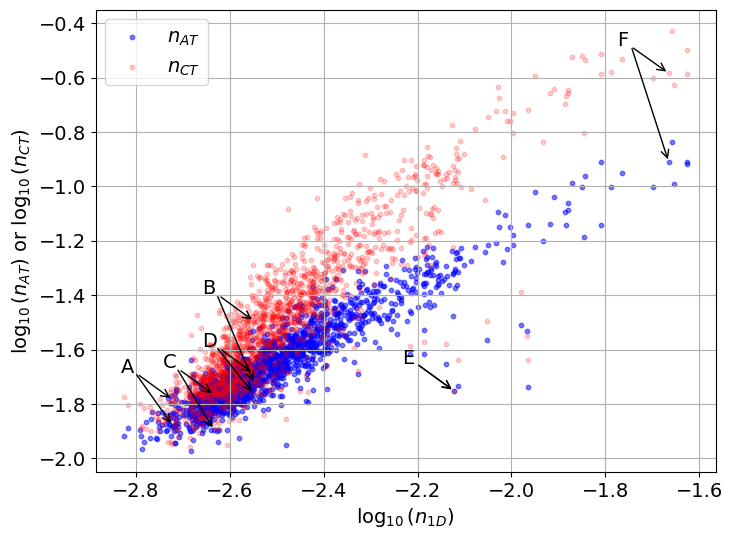

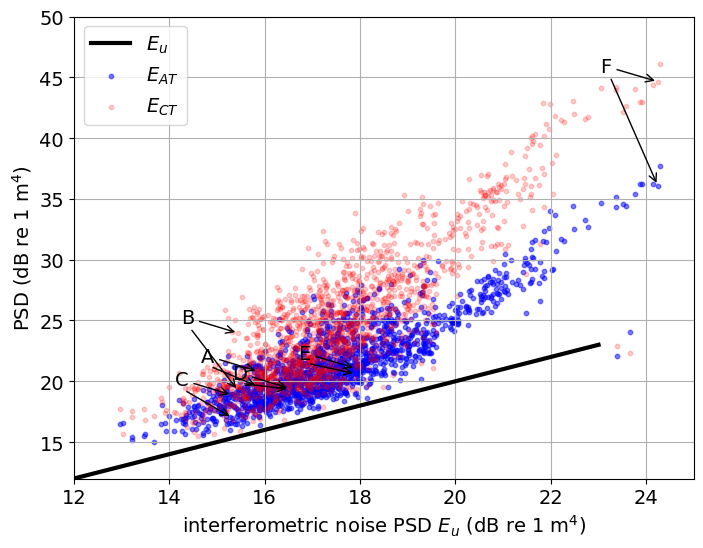

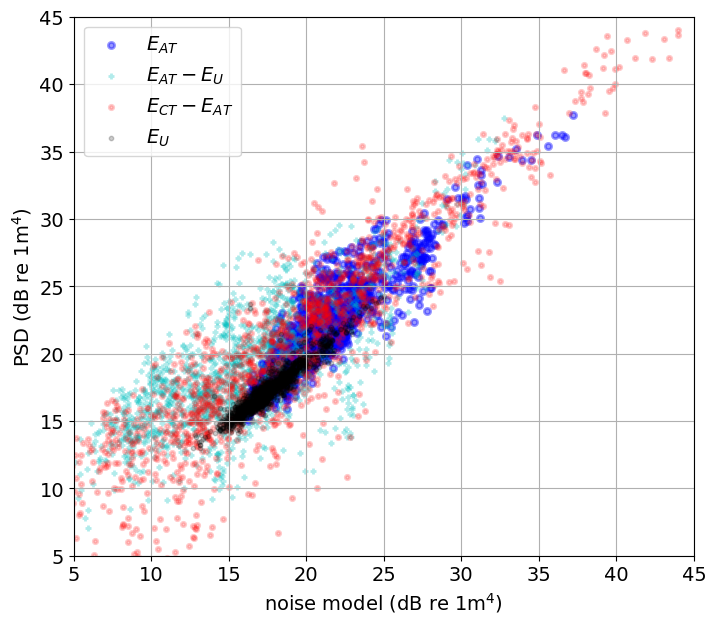

In [48]:
from scipy.stats import linregress

filter_factor=4.376579  # OBP filter variance loss 

dxdy=(250*235)
DXDY=(4E6)
# mean of PSD of OPB filter is 4.376579 
# mean of PSD of Hamming filter is : 7.1339
X=df_seg["noiseamp_m"].values.copy() # back to meters
V=ds_seg["uncertainty_std"].values.flatten().copy()   # used to flag bad segments
Y=np.sqrt(ds_seg["noise_250_CT"].values.flatten().copy()/(filter_factor*dxdy))   
Z=np.sqrt(ds_seg["noise_250_AT"].values.flatten().copy()/(filter_factor*dxdy))   


#W=2.5*ds_seg["uncert"].values.flatten().copy()*DXDY   
W2=7.1339*(ds_seg["uncert"].values.flatten().copy()**2)*DXDY*filter_factor  
W=(ds_seg["uncertainty"].values.flatten().copy()**2)*dxdy*filter_factor
U=(ds_seg["uncertainty_std"].values.flatten().copy()**2)*dxdy*filter_factor

#plt.figure(figsize=(8,7))
#sc = plt.scatter(W,U/W, c='b', lw=2, s=20, alpha=0.4,label=r'std')
#plt.xlim([0,200])
#plt.ylim([0,0.1])

W3=((ds_seg["uncertainty"].values.flatten().copy()**2+ds_seg["uncertainty_near"].values.flatten().copy()**2+ds_seg["uncertainty_far"].values.flatten().copy()**2)/3)*dxdy*4.376579
W5=(ds_seg["uncertainty_near"].values.flatten().copy()**2)*dxdy*filter_factor
W6=(ds_seg["uncertainty_far"].values.flatten().copy()**2)*dxdy*filter_factor

#W2=7.1339*(ds_seg["uncert"].values.flatten().copy())*DXDY*4.376579   
#W=(ds_seg["uncertainty"].values.flatten().copy())*dxdy*4.376579
#W3=((ds_seg["uncertainty"].values.flatten().copy()+ds_seg["uncertainty_near"].values.flatten().copy()+ds_seg["uncertainty_far"].values.flatten().copy())/3)*dxdy*4.376579
#W3=(ds_seg["uncertainty_near"].values.flatten().copy())*dxdy*4.376579

inds=np.where(V<0.05)[0]   # worked with sigma0_std before ...
print('LEN :',len(V),len(inds),np.nanmax(V))

fCT=0.56;fAT=0.34
print('corrections:',10**(fAT/10),10**(fCT/10))

# remove outliers (sigma0 bloom)
#Z[176*8:178*8]=0.  # 495
#Y[176*8:178*8]=0.  # 495
#W[176*8:178*8]=0.  # 495


print('Max u :',np.nanmax(df_seg["uncert"]),2.5*dxdy,np.nanmax(W),' dB:',10*np.log10(np.nanmax(W)))
logY=10*np.log10(Y[inds]**2*dxdy*filter_factor)+fCT  # PSD in dB 
logZ=10*np.log10(Z[inds]**2*dxdy*filter_factor)+fAT  # PSD in dB 

logW=10*np.log10(W[inds])
logW2=10*np.log10(W2[inds])
logW3=10*np.log10(W3[inds])
logW5=10*np.log10(W5[inds])
logW6=10*np.log10(W6[inds])


mask = np.where(Z > 0.)[0]
#print(len(mask),'TEST:',Z[17*8:18*8])
#Z[17*8:19*8]=0.
#Z[109*8:111*8]=0.  # 533
#Z[117*8:119*8]=0.  # 537
#Z[139*8:140*8]=0.  # 548
#Z[141*8:142*8]=0.  # 549
#Z[151*8:152*8]=0.  # 554
#Z[164*8:165*8]=0.  # 561
#Z[176*8:178*8]=0.  # XXX sigma0 bloom
#Z[186*8:188*8]=0.  # 574


# Drop NaNs to avoid invalid correlations
mask = np.where(Z > 0.0)[0]
print(len(mask),'TEST:',Z[17*8:18*8])
Xc,  Zc = X[mask], Z[mask]

r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr 1D , 2D= {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)
print('Theoretical slope for white noise:',np.sqrt((DXDY)/dxdy))

# This tests the effect of sampling error (should use chi2 instead of Gaussian ...) 
#Zc=Xc*10**(0.08*np.random.normal(loc=0, scale=1, size=len(Xc)))
#r_XZ, p_XZ = pearsonr(Xc, Zc)
#slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
#print(f"Corr 1D , 2D= {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)

####################### First panel
mpl.rcParams.update({'figure.figsize':[9,5.4],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})
plt.figure(figsize=(8,6))
sc = plt.scatter(np.log10(Xc),np.log10(Zc), c='b', s=10, alpha=0.5,label='$n_{AT}$')
sc = plt.scatter(np.log10(X),np.log10(Y), c='r', s=10, alpha=0.2,label='$n_{CT}$')
# ---- points to annotate ----

for m, n, label in annotation_points:
    i = m*8 + n
    x_val = np.log10(X[i]);y_val = np.log10(Y[i]);z_val = np.log10(Z[i])
    print(label,x_val,y_val,z_val) 
    # annotate Y (red)
    plt.annotate(label,xy=(x_val, y_val),xytext=(x_val-0.11, y_val+0.1),arrowprops=dict(arrowstyle="->"))
    # arrow to Z (blue)
    plt.annotate("",xy=(x_val, z_val),xytext=(x_val-0.08, y_val+0.1),arrowprops=dict(arrowstyle="->"))
plt.ylabel(r'$\log_{10}(n_{AT})$ or $\log_{10}(n_{CT})$')
plt.xlabel(r'$\log_{10}(n_{1D})$')
plt.grid(True)
plt.legend()
plt.savefig('Figure_5a_'+ana_tag+'.pdf')


####################### 2nd panel
mpl.rcParams.update({'figure.figsize':[9,5.4],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})
plt.figure(figsize=(8,6))
sc = plt.plot([12,23],[12,23], c='k', lw=3,label=r'$E_u$')
#sc = plt.scatter(logW,logW5, c='m', s=10, alpha=0.2,label=r'$E_{u}$ near')
#sc = plt.scatter(logW,logW6, c='c',marker='+', s=20, alpha=0.3,label=r'$E_{u}$ far')
sc = plt.scatter(logW,logZ, c='b', s=10, alpha=0.5,label=r'$E_{AT}$')
sc = plt.scatter(logW,logY, c='r', s=10, alpha=0.2,label=r'$E_{CT}$')

# ---- points to annotate ----
for m, n, label in annotation_points:
    i = m*8 + n
    x_val = logW[i];y_val = logY[i];z_val = logZ[i]
    print(label,ds_seg["time"][m,n].values,ds_seg["ssh_filenames"][m].values,x_val,y_val,z_val) 
    # annotate Y (red)
    plt.annotate(label,xy=(x_val, y_val),xytext=(x_val-1.2, y_val+0.8),arrowprops=dict(arrowstyle="->"))
    # arrow to Z (blue)
    plt.annotate("",xy=(x_val, z_val),xytext=(x_val-1, y_val+0.4),arrowprops=dict(arrowstyle="->"))
#plt.ylabel(r'$E_{\mathrm{min}}$ or $E_{\mathrm{CT}}$ (dB re 1 m$^4$)')
plt.ylabel(r'PSD (dB re 1 m$^4$)')
plt.xlabel(r'interferometric noise PSD $E_{u}$ (dB re 1 m$^4$)')
plt.grid(True)
plt.legend()
plt.xlim([12,25])
plt.ylim([12,50])
plt.savefig('Figure_5b_'+ana_tag+'.pdf')



YZ=10*np.log10(Y[inds]**2*dxdy*filter_factor*(10**(fCT/10))-Z[inds]**2*dxdy*filter_factor*(10**(fAT/10)) )  # PSD in dB 
V=10*np.log10(Z[inds]**2*dxdy*filter_factor*(10**(fAT/10))-W[inds])  # PSD in dB 
#Vm=-18+10*np.log10((qkk_model_seg[inds]*hs_model_seg[inds])**2)
Vmfactor=-18
Vm=Vmfactor+10*np.log10((qkk_model_seg[inds]*hs_model_seg[inds])**2)

#Vm=Vmfactor+10*np.log10((0.75*qkk_nadir[inds]*hs_model_seg[inds])**2)

#Vm=2+10*np.log10((hs_model_seg[inds])**3)

betam=np.sqrt(10**(-1.8)*10**0.2*np.pi/(8-2*np.pi)/(2*np.pi)**2)

atan2=857*np.mean(1/np.arange(25,45,1))
kCT=2*np.pi*0.0008
alpham = np.sqrt(10**(-2.8)*2*256/((np.pi*2)**2)/(atan2*kCT)**2 -1)


print('betam:',betam, 'alpham:',alpham,atan2,kCT)
Y=logY
Z=logZ 
W=logW
mask = np.isfinite(Y) & np.isfinite(Z)
Zm=10*np.log10((16*np.exp(0.46*hs_model_seg[inds]))) #   np.log((0.08*1+0.08*hs_model_seg/4.37 ))))/log(10)  =   # log10(a)=log(a)/log(10)
Wm=10*np.log10((20*np.exp(0.23*hs_model_seg[inds]))) #   np.log((0.08*1+0.08*hs_model_seg/4.37 ))))/log(10)  =   # log10(a)=log(a)/log(10)
#Zm=np.log10((0.08+0.018*hs_model_seg[inds])*0.5*(1+0.2*(hs_model_seg[inds]/3)**1.5))
Wm2=9.5+10*np.log10(0.8+ (0.1*wnd_model_seg[inds]+hs_model_seg[inds]**2/5) )
Wm2=10.5+10*np.log10(0.8+ (0.15*wnd_model_seg[inds]+0.15*hs_model_seg[inds]**2) )

print('shapes:',np.shape(Zm),np.shape(Z))
print('fit factor:',(np.log(10)*1.9),(0.0008*1200))
#Ym=np.log10((qkk_model_seg*hs_model_seg)**0.9/110.)

Ym=-28+10*np.log10((qkk_model_seg[inds]*hs_model_seg[inds]**2)**2)

#Ym=-28+10*np.log10((0.75*qkk_nadir[inds]*hs_model_seg[inds]**2)**2)

#Ym=-28+10*np.log10((15*hs_model_seg[inds]**2)**2)


plt.figure(figsize=(8,7))
sc = plt.scatter(Zm,Z, c='b', lw=2, s=20, alpha=0.4,label=r'$E_{AT}$')
sc = plt.scatter(Vm,V, c='c',lw=2,marker='+', s=20, alpha=0.3,label=r'$E_{AT} - E_{U}$')
sc = plt.scatter(Ym,YZ, c='r',lw=2, s=10, alpha=0.2,label=r'$E_{CT}-E_{AT}$')
sc = plt.scatter(Wm2,W, c='k', s=10, alpha=0.2,label=r'$E_{U}$')
plt.xlabel(r'noise model (dB re 1m$^4$)')
plt.ylabel(r'PSD (dB re 1m$^4$)')
plt.xlim([5,45])
plt.ylim([5,45])
plt.legend()
plt.savefig('Figure_6_'+ana_tag+'.pdf')

# Drop NaNs to avoid invalid correlations
mask = np.isfinite(Y) & np.isfinite(Z)  & np.isfinite(Ym) & np.isfinite(YZ)   #& (Ym+YZ > 50)


Xc,  Zc = W[mask], Wm2[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr model Eu = {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)


Xc,  Zc = Zm[mask], Z[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr model Hs = {r_XZ:.3f}  (s={slope_XZ:.3f})",intercept_XZ)

# Emin with Hs only: Corr model Hs = 0.906  (s=1.027) -1.0694075964126597 

Xc,  Zc = Ym[mask], YZ[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr nHQ (X, Z) = {r_XZ:.3f}  (s={slope_XZ:.3f})", intercept_XZ)

Xc,  Zc = np.sqrt(Ym[mask]**2+Zm[mask]**2), Y[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr(X, Z) = {r_XZ:.3f}  (s={slope_XZ:.3f})")

mask = np.isfinite(V) & np.isfinite(Vm)
Xc,  Zc = Vm[mask], V[mask]
r_XZ, p_XZ = pearsonr(Xc, Zc)
slope_XZ, intercept_XZ, r_XZ, p_XZ, stderr_XZ = linregress(Xc, Zc)
print(f"Corr(Vm, V) = {r_XZ:.3f}  (s={slope_XZ:.3f})")


dkdk=dkxs.values * dkys.values
NPSD=(0.01*ds_seg["noise_250_AT"].values.flatten())**2/(dkdk)
print('10th percentile:',dkdk,np.percentile(NPSD, 10),np.sqrt(np.percentile(NPSD, 10)*dkdk))

tant=35/857
arctant=857*np.mean(1/np.arange(15,55,1))
arctanf=857*np.mean(1/np.arange(35,55,1))
arctann=857*np.mean(1/np.arange(15,35,1))
ratio=(arctann/arctanf)**2
print('arctan factor, ratio, log:',857/arctant,ratio,np.log10(ratio)*10)
print('theory factor = 100*dkx*kd/(32*tan theta):',((2*np.pi)**2)*100*2E-4*8E-4*arctant/32,' empirical ;',1/1200)
print('theory factor = 100*dkx*kd/(4* tan theta):',((2*np.pi)**2)*100*2E-4*8E-4*arctant*np.sqrt(8)/32,' empirical ;',1/1200,1200*0.000833/0.00055988,1/(1200*0.0008333333/0.00055988))
print('theory factor = :',((2*np.pi)**3)*1E-3*arctant/32,' empirical ;',1/(1200*100*2E-4),'ratio=',1/(1200*100*2E-4)/(((2*np.pi)**3)*1E-3*arctant/32))



In [49]:

mpl.rcParams.update({'figure.figsize':[10,6],'axes.grid' : True,'font.size': 10,'savefig.facecolor':'white'})
Xn=100*uncert_seg_var.copy()

def plot_spectrum(i, s, mode):
    fig = plt.figure(figsize=(20, 6))
    gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[20, 1],   # small row for colorbars
    width_ratios=[1, 1, 1, 1],
    hspace=0.35,
    wspace=0.12)

    axs = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3])
    ]

    cax0 = fig.add_subplot(gs[1, 0])
    cax1 = fig.add_subplot(gs[1, 1])
    cax2 = fig.add_subplot(gs[1, 2])
    # gs[1,2] intentionally unused

    fs1 = 20

    # ==========================================================
    # 1️⃣ --- LOAD SSH FILE (per strip) ---
    # ==========================================================
    lo2=ds_seg["lon"][i,s].values
    la2=ds_seg["lat"][i,s].values
    ssh_file = ds_seg["ssh_filenames"][i].item()

    print('ssh_file=',ssh_file)
    ssh_OK=1
    if ssh_file is None:
        print("SSH file not defined.")
        ssh_OK=0
    if ssh_OK==1:
        file_path = Path(ssh_file)    # without folder path
        ssh_file = file_path.name           # without path
        ssh_full = Path(ssh_Unsmoothed_D_folder) / Path(ssh_file)           # without path


    print('I,S:',i,s,ssh_file)
    if ssh_file is None:
        print("SSH file not found.")
        return

    if good_strips_list[i,1]==0 :
        ddl = xr.open_dataset(ssh_file, group='left') 
    else: 
        ddl = xr.open_dataset(ssh_file, group='right') 
    if mode == "ssh" :
         L2_variable='ssha_karin_2'
         labelSWOT='ssh (m)'
         cmapSWOT=lightcmap
    if mode == "sigma0" :
         L2_variable="sig0_karin_2"
         labelSWOT='sigma0 (dB)'
         cmapSWOT='viridis'
    if mode == "uncertainty" :
         L2_variable="uncertainty"
         labelSWOT='uncertainty (dB)'
    if mode == "swh" :
         L2_variable="ssh_karin_2"

# i1 values [ 39  79 119 319 359 399]
# This is how spectra and indices were given when computing spectra: 
#        ddll = xr.open_dataset(file_swot, group='left') # 82941 , 240
#        ddlr = xr.open_dataset(file_swot, group='right') # 82941 , 240
#        varlis1=['ssh_karin_2','sig0_karin_2','ssh_karin_2_qual','latitude','longitude','time','ssh_karin_uncert'] 
#        varlist=['ssh_karin_2','sig0_karin_2','ssh_karin_2_qual','latitude','longitude','ssh_karin_uncert'] 
#        ddla = ddlr[varlis1].copy().pad(num_pixels=(279,0))  # Make a copy of the original ddll to avoid modifying it in place
#        for thisvar in varlist :
#            ddla[thisvar][:, 0:240] = np.flip(ddll[thisvar].values, axis=1) 
        
    j1 = int(j1_indices[i, s])-41
    j2 = int(j2_indices[i, s])+41
    print('j1,j2:',j1,j2)
    if good_strips_list[i,1]==0 :
        i1 = int(i1_indices[i, s])-39
        i2 = int(i2_indices[i, s])+40
        ix = -240-18+i1
        dataSWOT = np.flip(ddl[L2_variable], axis=1)[j1:j2, i1:i2] 

    else: 
        i1 = int(i1_indices[i, s])-40-279
        i2 = int(i2_indices[i, s])+39-279
        ix = i1+19
        dataSWOT = ddl[L2_variable][j1:j2, i1:i2] 


    print('i1,i2:',i1,i2)
    lat = ddl.latitude.values
    lon = ddl.longitude.values
    sig0 = ddl.sig0_karin_2   #sigma0
    unce = ddl.ssh_karin_uncert   #sigma0
    #flas = ddl.quality_flag

    # ==========================================================
    # 3️⃣ --- BUILD SSH PANEL ---
    # ==========================================================
    dx, dy, indxc, ISHIFT, *_ = swell.spec_settings_for_L3(1, 'alpha')

    print('ind:',i1,i2,j1,j2,'##',indxc,ix,np.shape(ddl[L2_variable]))
    latmean=0.5*(lat[j2-20, i2-20 ]+ lat[j1+20, i1+20 ])
    lonmean=0.5*(lon[j2-20, i2-20 ]+ lon[j1+20, i1+20 ])

    X= (np.arange(dataSWOT.shape[1]) + ix) * dx / 1000
    Y= (np.arange(dataSWOT.shape[0]) - j1) * dy / 1000
    Y=Y-Y[0]


    if mode == "ssh" :
        mybox=dataSWOT
        detrenda = mybox - np.nanmean(mybox)
        temp=detrenda.values
        detrenda=detrend_2d_quadratic_nan(temp)
        amax = np.nanmax(detrenda)
        amin=-1*amax
    else: 
        detrenda=dataSWOT
        amax = np.nanmax(detrenda)
        amin = np.nanmin(detrenda)


    print('lon,lat:',lo2,la2,'##',lonmean,latmean,'##',X[0],X[-1],' max value:',amax)

    #im0 = axs[0].pcolormesh(X[i1:i2], Y[j1:j2], detrenda, cmap=lightcmap,vmin=-amax, vmax=amax,rasterized=True )
    #fig.colorbar(im0, cax=cax0,orientation='horizontal',label='surface elevation (m)')

    im0 = axs[0].pcolormesh(X, Y, detrenda,cmap=cmapSWOT,vmin=amin, vmax=amax,rasterized=True )
    fig.colorbar(im0, cax=cax0,orientation='horizontal',label=labelSWOT)
    
    #plt.colorbar(im0, ax=axs[0],
    #             label='surface elevation (m)',
    #             location='bottom', shrink=0.8)

    axs[0].set_xlabel('cross-track (km)', fontsize=fs1)
    axs[0].set_ylabel('along-track (km)', fontsize=fs1)
    axs[0].set_title('latitude: '+f"{latmean:.2f}"+'°')
    axs[0].grid(False)


    kx2s = ds_seg["fx2D"].values
    ky2s = ds_seg["fy2D"].values
    # Maximum energy marker
    fy_max = int(ds_seg.max_indices_fy[i, s].values)
    fx_max = int(ds_seg.max_indices_fx[i, s].values)
    # Minimum energy marker
    fy_min = int(ds_seg.min_indices_fy[i, s].values)
    fx_min = int(ds_seg.min_indices_fx[i, s].values)
    # ==========================================================
    # 4️⃣ --- SPECTRUM PANEL ---
    # ==========================================================
    E=ds_seg["Efxfy_f"][i, s].values/ds_seg["Efxfy_n"][i, s].values
    im1 = axs[2].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=-5, vmax=5),rasterized=True, cmap='seismic')
    axs[2].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
    axs[2].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')

    
    #plt.colorbar(im1, ax=axs[1],
    #             label='dB re 1 m$^4$',
    #             location='bottom', shrink=0.8)

    fig.colorbar(im1, cax=cax2,
             orientation='horizontal',
             label='ratio far/near (dB)')

    axs[1].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)

    # ==========================================================
    # 4️⃣ --- SPECTRUM PANEL ---
    # ==========================================================
    E = ds_seg["Efxfy"][i, s].values*L3Snc.filter_PTR

    im1 = axs[1].pcolormesh(kx2s * 1000,ky2s * 1000,10 * np.log10(E),norm=mcolors.Normalize(vmin=0, vmax=50),rasterized=True, cmap='seismic')

    fig.colorbar(im1, cax=cax1,
             orientation='horizontal',
             label='dB re 1 m$^4$')

    axs[1].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)
    axs[1].scatter(kx2s[fy_min, fx_min] * 1000,ky2s[fy_min, fx_min] * 1000,color='blue', s=50,edgecolor='white')
    axs[1].scatter(kx2s[fy_max, fx_max] * 1000,ky2s[fy_max, fx_max] * 1000,color='red', s=50,edgecolor='white')
    parts = ssh_file.split('_')
    axs[1].set_title(parts[-6]+'_'+parts[-5]+'_'+parts[-4])


        
    X=ds_seg["noise_250_AT"][:, s].values
    Y=ds_seg["noise_250_CT"][:, s].values
    Z=np.sqrt(Y**2-X**2)
    #sc = axs[2].scatter(df_seg["noiseamp_m"], 3*ds_seg["noise_250k"], c='r', s=10, alpha=0.3,label='min of 2D spectrum from 250 m grid')

    axs[3].scatter( np.log10(Xn[:,s]*100), np.log10(Y), c='r', s=10, alpha=0.5,label='amp max')
    axs[3].scatter( np.log10(Xn[i,s]*100), np.log10(Y[i]), c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')
    #axs[3].scatter( np.log10(Xn[:,s]*100), np.log10(Z), c='g', s=10, alpha=0.2,label='max-min')
    #axs[3].scatter( np.log10(Xn[i,s]*100), np.log10(Z[i]), c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')
    axs[3].scatter( np.log10(Xn[:,s]*100), np.log10(X), c='b', s=10, alpha=0.5,label='amp min')
    axs[3].scatter( np.log10(Xn[i,s]*100), np.log10(X[i]), c='k', s=80, alpha=0.4)  #label='min of 2D spectrum from 250 m grid')

    axs[3].set_xlabel('4-10 km SSH noise amplitude (along-track) (cm)')
    axs[3].set_ylabel('other noise metric (cm)')
    axs[3].yaxis.tick_right()                 # ticks on the right
    axs[3].yaxis.set_label_position("right")  # ylabel on the right    #plt.title('SSH noise at different scales (for 40-km long segments)')
    #plt.legend()
    axs[3].grid(True)
    axs[3].legend()
    plt.savefig('test.pdf') 

ToggleButtons(description='SWOT map:', options=('ssh', 'sigma0', 'uncertainty', 'swh'), value='ssh')

Output()

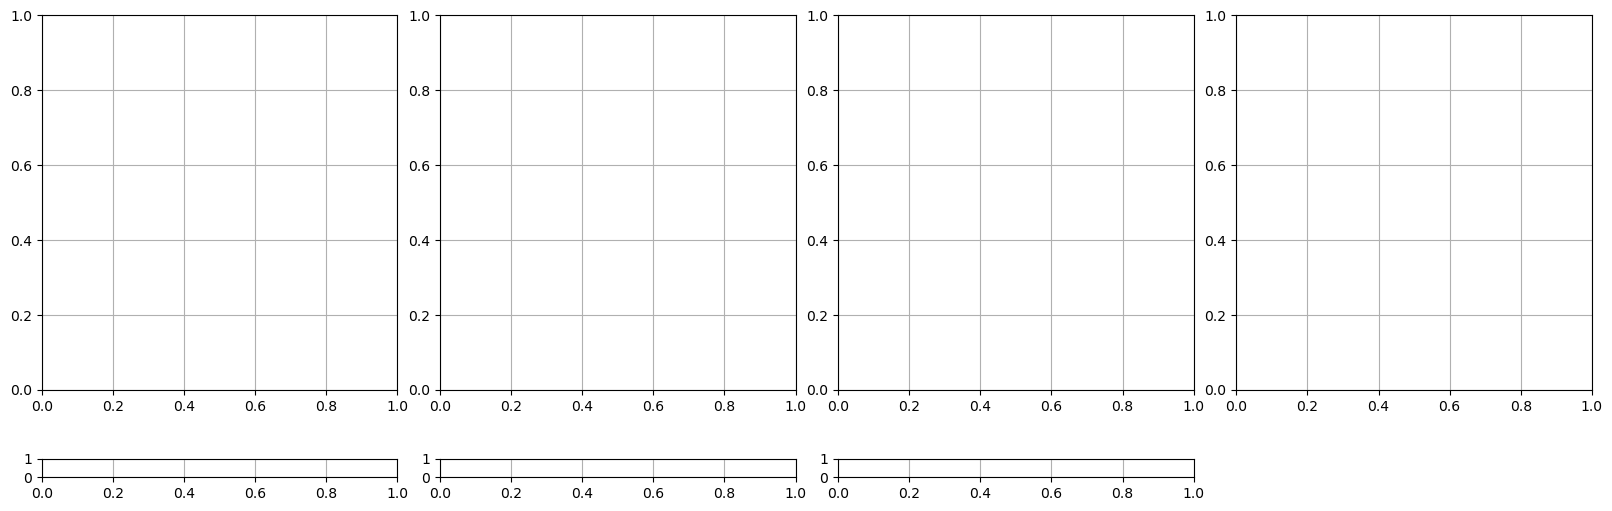

In [50]:
plot_mode = ToggleButtons(
    options=["ssh", "sigma0","uncertainty","swh"],
    value="ssh",
    description="SWOT map:",
    button_style="",  # or 'info'
)

strip_slider = IntSlider(
    min=0, max=len(good_strips_list)-1, step=1,
    value=0, description="strip"
)
seg_slider = IntSlider(
    min=0, max=num_seg-1, step=1,
    value=0, description="segment"
)


slider_grid = VBox([
    strip_slider,
    seg_slider
])

out = interactive_output(
    plot_spectrum,
    {
        "i": strip_slider,
        "s": seg_slider,
        "mode": plot_mode, 
    },
)

display(plot_mode, slider_grid, out)

#interact(
#    plot_spectrum,
#    i=IntSlider(min=0, max=len(good_strips_list)-1, step=1, value=0, description="cycle/side index"),
#    s=IntSlider(min=0, max=num_seg-1, step=1, value=0, description="segment"),
#)


#points = [(17,3,'E'),(123,3,'C'),(183,7,'A'),(171,6,'F'),(110,6,'D'),(183,1,'B')]


<class 'xarray.core.dataarray.DataArray'>
kxmax: 0.004000000189989805 0.004052685108035803
kxmax: 0.00020000000949949026 0.00020263425540179014
dkx: 2.5e-05 2.5e-05
Found model?  91673 1 0.004574854 <class 'xarray.core.dataarray.DataArray'>
TEST: 91673 1 2023-07-02T07:00:00 -131.0 -53.5 0.004574854 ## 10.964784 78.31813504207817 (21, 20) (21, 20)
Hs: nan nan nan nan nan nan nan  HIG: 2.926325798034668 0.012614897452294827


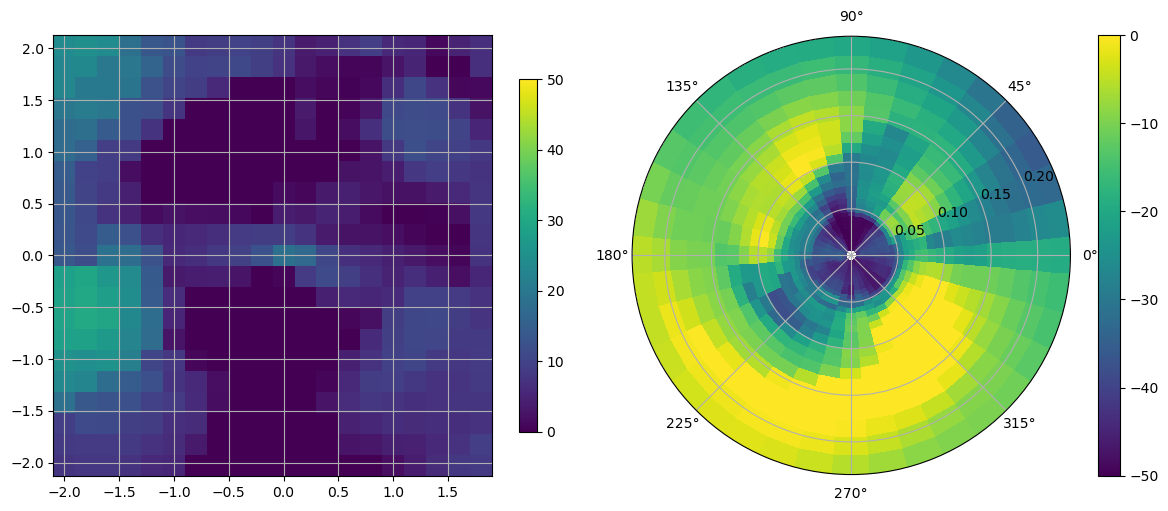

In [51]:
# prepares aliasing calculations :
firstg=0

nX2=80
nY2=84
m=8
n=8
nxtile=nX2*2//m  # cross-track
nytile=nY2*2//n  # along-track

kx2s = ds_seg["fx2D"].as_numpy() #.values
ky2s = ds_seg["fy2D"].as_numpy() #.values
print(type(kx2s))
kxmax=-2*kx2s[0,0].values
kymax=-2*ky2s[0,0].values
print('kxmax:',kxmax,kymax)

nkxr=nxtile      # twice the SWOT range to allow aliasing computation 
nkyr=nytile
dkxr=kxmax/nkxr
dkyr=kymax/(nkyr-1)  # only true in nkyr is odd ?? 
print('kxmax:',dkxr,dkyr)
print('dkx:',dkx,dky)
kxr=np.linspace(-nkxr*dkxr,(nkxr-1)*dkxr,nkxr*2)
kyr=np.linspace(-nkyr*dkyr,(nkyr-1)*dkyr,nkyr*2)
fx_wreg=kxr*1000
fy_wreg=kyr*1000
kxr2, kyr2 = np.meshgrid(kxr,kyr,indexing='ij') 
kn=np.sqrt(kx2**2+ky2**2)*1000
ik1=(nxtile+1)//2;ik2=ik1+nxtile
jk1=(nytile+1)//2;jk2=jk1+nytile
x_xt, w_xt, f_xt, H_xt = get_obp_filter(L_filt = 0.980, f_axis = fx_wreg, plot_flag = False, kernel="parzen")
x_at, w_at, f_at, H_at = get_obp_filter(L_filt = 1, f_axis = fy_wreg, plot_flag = False, kernel="bharris")
x_at, w_at, f_obp, H_ptr = get_obp_filter(L_filt = 3, sampling_in = 0.0125,f_axis = fy_wreg, plot_flag = False, kernel="alejandro_azptr")

H = np.repeat(np.array([H_xt]), len(H_at), axis=0).T * np.repeat(np.array([H_at]), len(H_xt), axis=0)
Hptr = np.repeat(np.array([H_ptr]), len(H_xt), axis=0)
H2=H*Hptr                     # note that when model data is also used, H3 is defined below to include az cut-off 
H3=H2    # OPB and PTR
#H3=Hptr*0+1
Hazc=H3*0+1
HH3=H3[ik1:ik2,jk1:jk2].T
HHP=Hptr[ik1:ik2,jk1:jk2].T
HHO=H[ik1:ik2,jk1:jk2].T

angt=ds_seg["track_angle"][0,0].values
filetr='/media/ardhuin/FabLinux/WW3-CCI/SWOT_WW3-GLOB-30M_202303_trck.nc'
filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBIG/SWOTIG_WW3-GLOB-30M_202307_trck.nc'
#filetr='/media/ardhuin/FabLinux/WW3-SWOT/GLOBAL_REF102040/SWOT_WW3-GLOB-30M_202303_trck.nc'
ds_ww3t = xr.open_dataset(filetr)
modang=np.mod(90-ds_ww3t.direction.values,360)
moddf=ds_ww3t.frequency2.values-ds_ww3t.frequency1.values
modf=ds_ww3t.frequency.values
modnth=np.shape(modang)[0]
moddth=(2*np.pi/modnth)
timec=np.datetime64('2023-03-30T21:33:30.832687');lo2=229.1592662363636;la2=-53.58133710181818 
timec=np.datetime64('2023-07-03T06:44:15.959962');lo2= 230.81456581043474;la2=-56.18616504869565 
timec=np.datetime64('2023-07-02T06:52:49.767811');lo2= 229.1592662363636 ;la2=-53.58133710181818
modspec,indww3,modelfound,timeww3,lonww3,latww3,distww3,U10,Udir,dpt=swell.SWOTfind_model_spectrum(ds_ww3t,lo2,la2,timec)
print('Found model? ',indww3,modelfound,distww3,type(modspec))
efth=modspec.values
interp=None
Eta_WW3_obp_H2,interp = \
                      swell.wavespec_Efth_to_kxky_SWOT_fast(efth,modf,moddf, modang,moddth,f_xt,f_at,H3, \
                      kxmax,kymax,dkx,dky,dkxr,dkyr,nxtile,nytile,doublesided=0,verbose=0,aliasing=False,trackangle=angt*np.pi/180,interp=interp)

#Eta_WW3_obp_H2,Eta_WW3_obp_H,Eta_WW3_noa_H2,Eta_WW3_res,Eta_WW3_c,Ekxky,kxm,kym,ix1,iy1,interp=swell.wavespec_Efth_to_kxky_SWOT(efth,modf,moddf, modang,moddth,f_xt,f_at,H,Hazc,H3,kxmax,kymax,dkx,dky,dkxr,dkyr,nkxr,nkyr,depth=3000.,doublesided=0,verbose=0,trackangle=0,interp=None) 

array1=HH3*0+1
print('TEST:',indww3,modelfound,timeww3,lonww3,latww3,distww3,'##',np.nanmax(modspec.values),np.nanmax(Eta_WW3_obp_H2),np.shape(Eta_WW3_obp_H2),np.shape(kx2s))
Hs,Lmm1,LE,Lm,dm,spr,Q18=swell.SWOTspec_to_HsLm(Eta_WW3_obp_H2,kx2s,ky2s,HH3,array1,angt,doublesided=0)    
EIG=np.sum(np.sum(modspec[0:nIG,:],axis=1)*moddth*moddf[0:nIG]).values
Etot=np.sum(np.sum(modspec[:,:],axis=1)*moddth*moddf[:]).values
print('Hs:', Hs,Lmm1,LE,Lm,dm,spr,Q18,' HIG:',4*np.sqrt(Etot),4*np.sqrt(EIG))


fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(Eta_WW3_obp_H2/HHO), vmin=0, vmax=50, 
#im=ax1.pcolormesh(kx2s*1000, ky2s*1000, 10*np.log10(HHO), vmin=-30, vmax=10,
                  cmap='viridis', rasterized=True)
plt.colorbar(im, ax=ax1, shrink=0.8)

nfp=40
ax2 = fig.add_subplot(1,2,2, projection='polar', theta_offset=0, theta_direction=1)
im=ax2.pcolormesh(modang*np.pi/180, modf[0:nfp], 10*np.log10(0.00001+modspec[0:nfp,:]), vmin=-50, vmax=0,cmap='viridis')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

#TEST: 1406698 1 2023-03-30T21:30:00 -131.0 -53.5 0.004574854 ## 12.72072 102490.67012096693
#Hs: 2.426762500819739 782.964225641062 662.3451255763952 832.3999168759932 87.87053806344622 56.62427362301565 66.32555798407326 102490.67012096693


In [ ]:
# Quick check on dofs ...

from scipy.stats import chi2

# Degrees of freedom
k_values = [2, 8, 16, 64, 128]

# Confidence level for 1-sigma (68.27%)
lower_percentile = 0.1585
upper_percentile = 0.8415

for k in k_values:
    # Get the 1-sigma interval
    lower = chi2.ppf(lower_percentile, k)
    upper = chi2.ppf(upper_percentile, k)

    # Normalize by the mean (k)
    lower_norm = lower / k
    upper_norm = upper / k

    # Convert to dB
    lower_dB = 10 * np.log10(lower_norm)
    upper_dB = 10 * np.log10(upper_norm)

    print(f"k = {k:3d}: Lower = {lower_dB:6.1f} dB, Upper = {upper_dB:6.1f} dB")